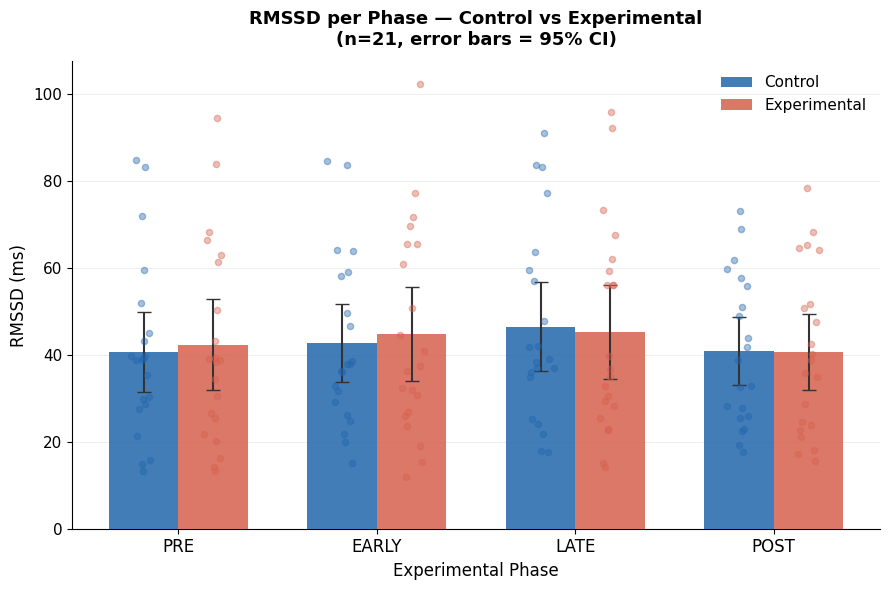

✅ Figure 3 saved: fig3_rmssd_per_phase.png


In [9]:
#RMSSD per phase bar plot (control vs experimental, CI error bars)
# ── FIGURE 3: RMSSD PER PHASE BAR PLOT ───────────────────────────────────────
phase_order = ['pre', 'early', 'late', 'post']
x     = np.arange(len(phase_order))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

for i, (condition, color) in enumerate(colors.items()):
    means, cis, all_vals = [], [], []

    for phase in phase_order:
        vals = df_phases[
            (df_phases['condition'] == condition) &
            (df_phases['phase']     == phase)
        ]['RMSSD'].dropna()
        means.append(vals.mean())
        cis.append(vals.sem() * stats.t.ppf(0.975, len(vals) - 1))
        all_vals.append(vals.values)

    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width,
           color=color, alpha=0.85,
           label=condition.capitalize(),
           yerr=cis, capsize=5,
           error_kw={'linewidth': 1.5, 'ecolor': '#333333'},
           zorder=3)

    # Overlay individual data points
    for j, vals in enumerate(all_vals):
        jitter = np.random.normal(0, 0.03, size=len(vals))
        ax.scatter(x[j] + offset + jitter, vals,
                   color=color, alpha=0.4, s=20, zorder=4)

style_ax(ax)
ax.set_xticks(x)
ax.set_xticklabels([p.upper() for p in phase_order], fontsize=12)
ax.set_ylabel('RMSSD (ms)', fontsize=12)
ax.set_xlabel('Experimental Phase', fontsize=12)
ax.set_title('RMSSD per Phase — Control vs Experimental\n'
             '(n=21, error bars = 95% CI)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig(fig_dir / "fig3_rmssd_per_phase.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 3 saved: fig3_rmssd_per_phase.png")

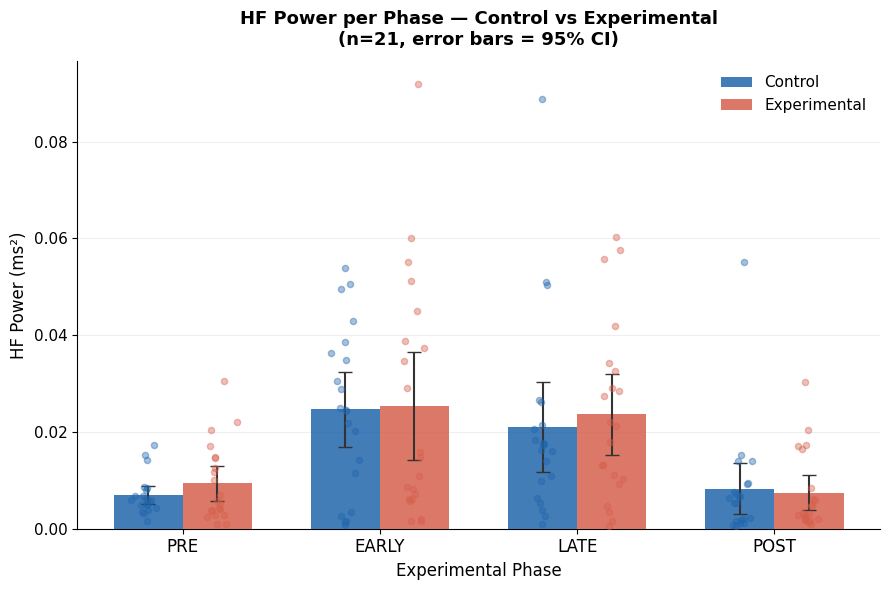

✅ Figure 4 saved: fig4_hf_per_phase.png


In [10]:
#HF per phase bar plot (control vs experimental, CI error bars)
# ── FIGURE 4: HF PER PHASE BAR PLOT ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

for i, (condition, color) in enumerate(colors.items()):
    means, cis, all_vals = [], [], []

    for phase in phase_order:
        vals = df_phases[
            (df_phases['condition'] == condition) &
            (df_phases['phase']     == phase)
        ]['HF'].dropna()
        means.append(vals.mean())
        cis.append(vals.sem() * stats.t.ppf(0.975, len(vals) - 1))
        all_vals.append(vals.values)

    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width,
           color=color, alpha=0.85,
           label=condition.capitalize(),
           yerr=cis, capsize=5,
           error_kw={'linewidth': 1.5, 'ecolor': '#333333'},
           zorder=3)

    # Overlay individual data points
    for j, vals in enumerate(all_vals):
        jitter = np.random.normal(0, 0.03, size=len(vals))
        ax.scatter(x[j] + offset + jitter, vals,
                   color=color, alpha=0.4, s=20, zorder=4)

style_ax(ax)
ax.set_xticks(x)
ax.set_xticklabels([p.upper() for p in phase_order], fontsize=12)
ax.set_ylabel('HF Power (ms²)', fontsize=12)
ax.set_xlabel('Experimental Phase', fontsize=12)
ax.set_title('HF Power per Phase — Control vs Experimental\n'
             '(n=21, error bars = 95% CI)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig(fig_dir / "fig4_hf_per_phase.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 4 saved: fig4_hf_per_phase.png")

In [ ]:
#exploring possible models

Median MDBF change: 0.25

Group assignments (split defined by experimental MDBF only):
subj_id  mdbf_exp_change  mdbf_ctrl_change           group
sub-002            0.125             0.250  Low Responders
sub-004           -1.000             0.125  Low Responders
sub-006            0.375             0.375 High Responders
sub-008           -1.625             0.125  Low Responders
sub-010            0.625             1.500 High Responders
sub-012           -0.250             0.125  Low Responders
sub-018            0.625             0.750 High Responders
sub-020            0.500             0.000 High Responders
sub-022           -0.125             0.500  Low Responders
sub-024            0.875             0.125 High Responders
sub-001            0.000             0.000  Low Responders
sub-003            1.000             0.625 High Responders
sub-005            1.125             0.500 High Responders
sub-007           -0.125            -0.250  Low Responders
sub-009            0.250    

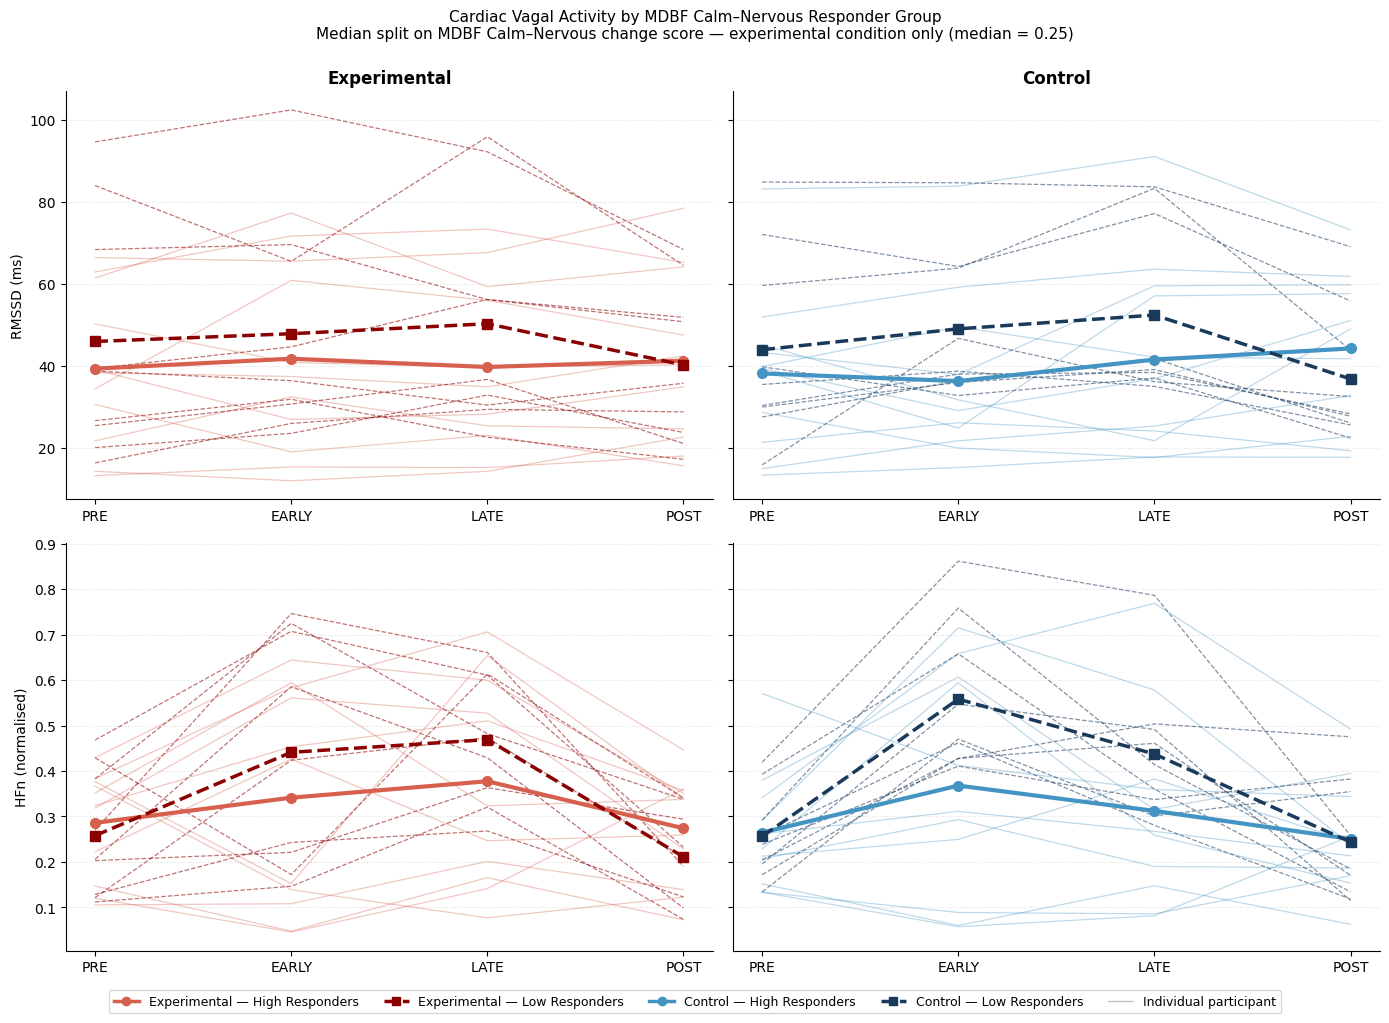


Figure saved → C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data\derivatives\group_figures\mdbf_split_combined.png


In [7]:
#Script 4: MDBF median split → HRV spaghetti plots (RMSSD and HFn)

#Median split on MDBF Ruhe-Unruhe change (post-pre mean score) from the EXPERIMENTAL session — values hardcoded directly.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import os

# ─── PATHS ────────────────────────────────────────────────────────────────────
BIDS_ROOT  = r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data"
DERIV      = os.path.join(BIDS_ROOT, "derivatives")
FIG_DIR    = os.path.join(DERIV, "group_figures")
os.makedirs(FIG_DIR, exist_ok=True)

HRV_T_FILE = os.path.join(DERIV, "hrv-analysis",
                           "task-BBSIG_per_phase_hrv-time.tsv")
HRV_F_FILE = os.path.join(DERIV, "hrv-analysis",
                           "task-BBSIG_per_phase_hrv-freq.tsv")

# ─── MDBF VALUES — hardcoded ──────────────────────────────────────────────────
# MDBF Ruhe-Unruhe change (post-pre mean) — experimental session
# VP order: 2, 4, 6, 8, 10, 12, 18, 20, 22, 24, 1, 3, 5, 7, 9, 11, 15, 19, 23, 25

VP_CODES = [2, 4, 6, 8, 10, 12, 18, 20, 22, 24,
            1, 3, 5,  7,  9, 11, 15, 19, 23, 25]

# MDBF Calm-Nervous change score — experimental session (used for median split)
MDBF_EXP  = [0.125, -1.0,   0.375, -1.625, 0.625, -0.25,  0.625, 0.5,
             -0.125, 0.875,  0.0,    1.0,    1.125, -0.125, 0.25,
              0.75, -0.125,  0.25,   0.75,   0.0]

# MDBF Calm-Nervous change score — control session (same subjects, same order)
MDBF_CTRL = [0.25,  0.125,  0.375,  0.125,  1.5,   0.125,  0.75,  0.0,
              0.5,   0.125,  0.0,    0.625,  0.5,  -0.25,   0.0,
              0.25,  0.0,    0.75,   0.625,  0.125]

# Build DataFrame — group assignment based on EXPERIMENTAL values only
mdbf = pd.DataFrame({
    "subj_id":         [f"sub-{v:03d}" for v in VP_CODES],
    "mdbf_exp_change":  MDBF_EXP,
    "mdbf_ctrl_change": MDBF_CTRL,
})

# ─── MEDIAN SPLIT ─────────────────────────────────────────────────────────────
median_val = np.median(MDBF_EXP)
print(f"Median MDBF change: {median_val}")

mdbf["group"] = np.where(
    mdbf["mdbf_exp_change"] >= median_val,
    "High Responders",   # at or above median: increased calmness
    "Low Responders"     # below median: little/no change
)

print("\nGroup assignments (split defined by experimental MDBF only):")
print(mdbf[["subj_id","mdbf_exp_change","mdbf_ctrl_change","group"]].to_string(index=False))
print(f"\n  High Responders (≥{median_val}): {(mdbf['group']=='High Responders').sum()}")
print(f"  Low Responders  (<{median_val}):  {(mdbf['group']=='Low Responders').sum()}")

# ─── LOAD HRV ─────────────────────────────────────────────────────────────────
def load_hrv(path):
    df = pd.read_csv(path, sep="\t")
    df.columns = df.columns.str.strip()
    df["phase"] = df["phase"].str.lower()
    return df

hrv_t = load_hrv(HRV_T_FILE).merge(mdbf, on="subj_id", how="left")
hrv_f = load_hrv(HRV_F_FILE).merge(mdbf, on="subj_id", how="left")

# ─── PLOT SETTINGS ────────────────────────────────────────────────────────────
PHASES     = ["pre", "early", "late", "post"]
PHASE_XLBL = ["PRE", "EARLY", "LATE", "POST"]
X_POS      = {p: i for i, p in enumerate(PHASES)}

# High relaxer = saturated, Low relaxer = pale
COLORS = {
    ("experimental", "High Responders"): "#D6604D",   # strong red
    ("experimental", "Low Responders"):  "#8B0000",   # dark red
    ("control",      "High Responders"): "#4393C3",   # medium blue
    ("control",      "Low Responders"):  "#1A3A5C",   # dark navy
}
LINESTYLE = {"High Responders": "-",  "Low Responders": "--"}
MARKERS   = {"High Responders": "o",  "Low Responders": "s"}
LINEWIDTH = {"High Responders": 3.0,  "Low Responders": 2.5}
ALPHA_IND = {"High Responders": 0.35, "Low Responders": 0.55}

# ─── COMBINED 2×2 FIGURE ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey="row")

fig.suptitle(
    "Cardiac Vagal Activity by MDBF Calm–Nervous Responder Group\n"
    f"Median split on MDBF Calm–Nervous change score — experimental condition only "
    f"(median = {median_val})\n",
    fontsize=11
)

MEASURES = [
    (hrv_t, "RMSSD", "RMSSD (ms)"),
    (hrv_f, "HFn",   "HFn (normalised)"),
]

for row_i, (hrv_df, col, ylabel) in enumerate(MEASURES):
    for col_i, condition in enumerate(["experimental", "control"]):

        ax      = axes[row_i, col_i]
        cond_df = hrv_df[hrv_df["condition"] == condition]

        for group in ["High Responders", "Low Responders"]:
            group_df = cond_df[cond_df["group"] == group]
            color    = COLORS[(condition, group)]
            ls       = LINESTYLE[group]

            # Individual spaghetti lines
            for subj, sub_df in group_df.groupby("subj_id"):
                pts = (sub_df[sub_df["phase"].isin(PHASES)]
                       .assign(x=lambda d: d["phase"].map(X_POS))
                       .sort_values("x")
                       .dropna(subset=[col]))
                if len(pts) < 2:
                    continue
                ax.plot(pts["x"], pts[col],
                        color=color, lw=0.9, ls=ls,
                        alpha=ALPHA_IND[group])

            # Group mean (bold)
            means = (group_df[group_df["phase"].isin(PHASES)]
                     .groupby("phase")[col].mean()
                     .reset_index()
                     .assign(x=lambda d: d["phase"].map(X_POS))
                     .sort_values("x"))
            ax.plot(means["x"], means[col],
                    color=color, lw=LINEWIDTH[group], ls=ls,
                    marker=MARKERS[group], ms=7, zorder=5, label=group)

        ax.set_xticks(range(len(PHASES)))
        ax.set_xticklabels(PHASE_XLBL, fontsize=10)
        ax.grid(axis="y", ls=":", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Labels
        if row_i == 0:
            ax.set_title(condition.capitalize(), fontsize=12,
                         fontweight="bold")
        if col_i == 0:
            ax.set_ylabel(ylabel, fontsize=10)

# Legend
handles = [
    mlines.Line2D([], [], color=COLORS[("experimental","High Responders")],
                  lw=2.5, ls="-",  marker="o", ms=6,
                  label="Experimental — High Responders"),
    mlines.Line2D([], [], color=COLORS[("experimental","Low Responders")],
                  lw=2.5, ls="--", marker="s", ms=6,
                  label="Experimental — Low Responders"),
    mlines.Line2D([], [], color=COLORS[("control","High Responders")],
                  lw=2.5, ls="-",  marker="o", ms=6,
                  label="Control — High Responders"),
    mlines.Line2D([], [], color=COLORS[("control","Low Responders")],
                  lw=2.5, ls="--", marker="s", ms=6,
                  label="Control — Low Responders"),
    mlines.Line2D([], [], color="grey", lw=0.9, alpha=0.5,
                  label="Individual participant"),
]
fig.legend(handles=handles, loc="lower center",
           ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
out = os.path.join(FIG_DIR, "mdbf_split_combined.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"\nFigure saved → {out}")

ASC median (experimental): 0.20

Subject overview:
subj_id    MDBF_grp           ASC_exp  ASC_grp
-------------------------------------------------------
sub-002   Low Responders      4.3       High Anxiety
sub-004   Low Responders      1.9       High Anxiety
sub-006   High Responders     nan       nan
sub-008   Low Responders      0.6       High Anxiety
sub-010   High Responders     0.2       High Anxiety
sub-012   Low Responders      0.1       Low Anxiety
sub-018   High Responders     0.2       High Anxiety
sub-020   High Responders     0.0       Low Anxiety
sub-022   Low Responders      0.8       High Anxiety
sub-024   High Responders     0.0       Low Anxiety
sub-001   Low Responders      0.2       High Anxiety
sub-003   High Responders     1.1       High Anxiety
sub-005   High Responders     0.0       Low Anxiety
sub-007   Low Responders      1.6       High Anxiety
sub-009   High Responders     0.2       High Anxiety
sub-011   High Responders     0.4       High Anxiety
sub-015   L

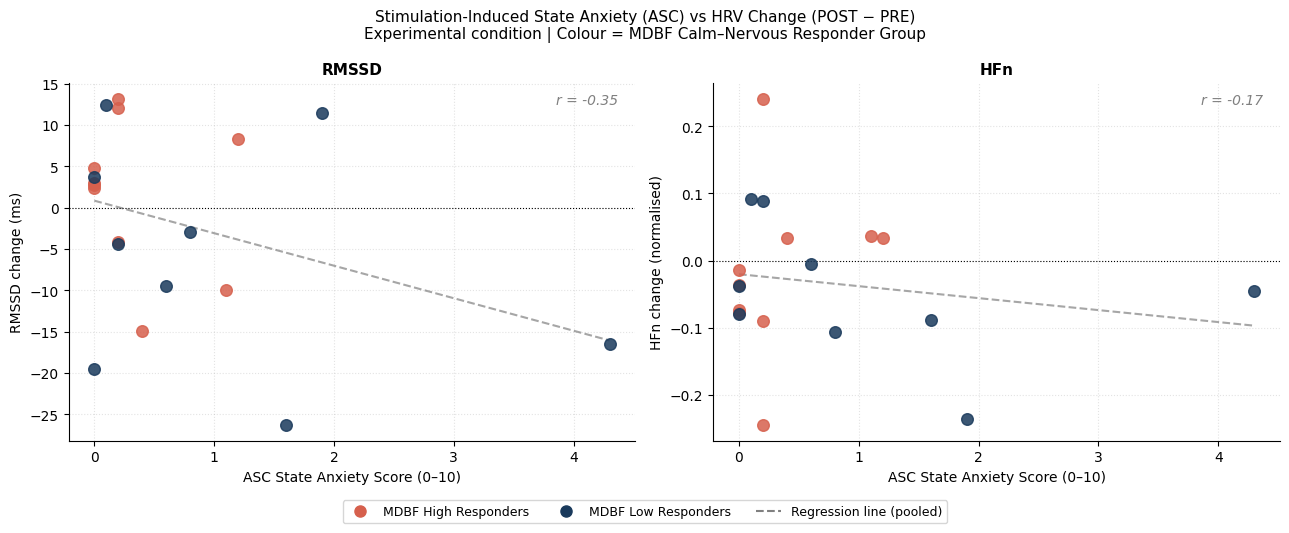

Saved → C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data\derivatives\group_figures\asc_anxiety_vs_hrv_change.png


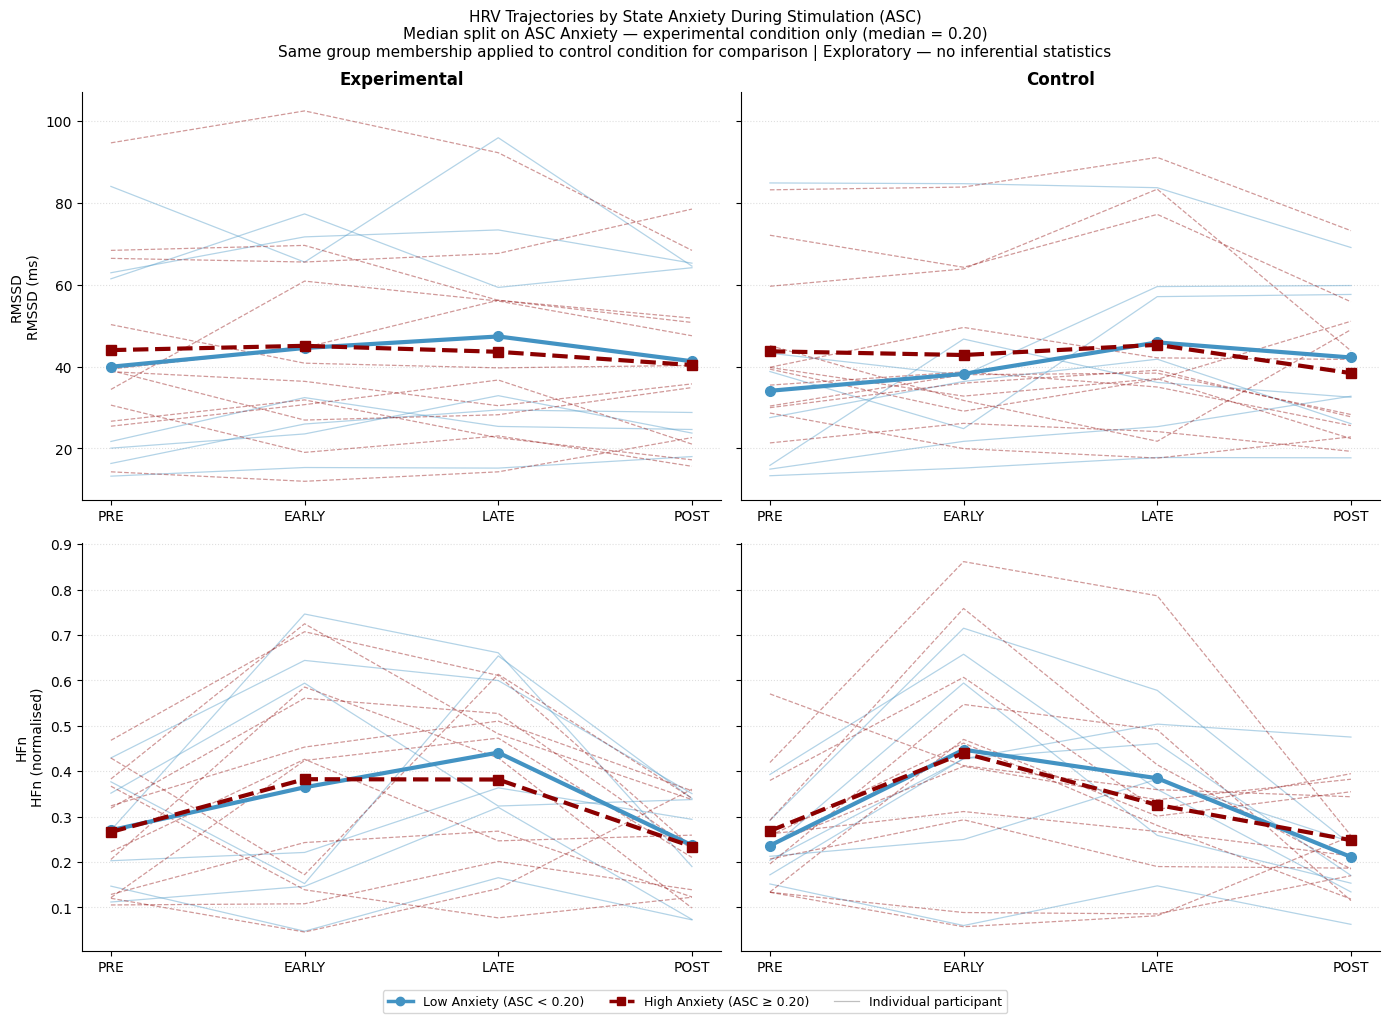

Saved → C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data\derivatives\group_figures\asc_anxiety_hrv_trajectories.png


In [35]:
#ASC Anxiety with HRV
"""
Script 6: ASC State Anxiety (experimental) × HRV — two focused graphics

PANEL 1 — Scatter: ASC anxiety (experimental) vs HRV change (POST - PRE)
  for RMSSD and HFn separately, with responder group colour-coded.
  Shows whether higher stimulation-induced anxiety predicts smaller HRV increase.

PANEL 2 — Trajectory overlay: HRV across phases (PRE→EARLY→LATE→POST)
  split by HIGH vs LOW ASC anxiety (median split on ASC_EXP),
  experimental condition only.
  Direct physiological correlate of the anxiety dissociation.

Key finding to visualise:
  Low Responders: ASC anxiety M=1.14 vs High Responders M=0.34
  Control condition: both groups M=0.42 (stimulation-specific effect)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import os

# ─── PATHS ────────────────────────────────────────────────────────────────────
BIDS_ROOT  = r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data"
DERIV      = os.path.join(BIDS_ROOT, "derivatives")
FIG_DIR    = os.path.join(DERIV, "group_figures")
os.makedirs(FIG_DIR, exist_ok=True)

HRV_T_FILE = os.path.join(DERIV, "hrv-analysis",
                           "task-BBSIG_per_phase_hrv-time.tsv")
HRV_F_FILE = os.path.join(DERIV, "hrv-analysis",
                           "task-BBSIG_per_phase_hrv-freq.tsv")

# ─── HARDCODED DATA ───────────────────────────────────────────────────────────
VP_CODES = [2,4,6,8,10,12,18,20,22,24,1,3,5,7,9,11,15,19,23,25]

MDBF_EXP = [0.125,-1.0,0.375,-1.625,0.625,-0.25,0.625,0.5,-0.125,0.875,
            0.0,1.0,1.125,-0.125,0.25,0.75,-0.125,0.25,0.75,0.0]

# ASC item 7 — state anxiety during stimulation (sub-025 missing → nan)
ASC_EXP  = [4.3,1.9,np.nan,0.6,0.2,0.1,0.2,0.0,0.8,0.0,0.2,
            1.1,0.0,1.6,0.2,0.4,0.0,1.2,0.0,0.0]

# MDBF median split group (defined in previous scripts)
median_mdbf = np.median(MDBF_EXP)
MDBF_GROUP  = ["High Responders" if m >= median_mdbf else "Low Responders"
               for m in MDBF_EXP]

# ASC median split (for trajectory plot) — exclude nan
asc_valid   = [v for v in ASC_EXP if not np.isnan(v)]
median_asc  = np.median(asc_valid)
ASC_GROUP   = ["High Anxiety" if (not np.isnan(v) and v >= median_asc)
               else ("Low Anxiety" if not np.isnan(v) else np.nan)
               for v in ASC_EXP]

print(f"ASC median (experimental): {median_asc:.2f}")
print("\nSubject overview:")
print(f"{'subj_id':10s} {'MDBF_grp':18s} {'ASC_exp':8s} {'ASC_grp'}")
print("-" * 55)
for i, vp in enumerate(VP_CODES):
    print(f"sub-{vp:03d}   {MDBF_GROUP[i]:18s}  {str(ASC_EXP[i]):8s}  "
          f"{ASC_GROUP[i]}")

# ─── LOAD HRV ─────────────────────────────────────────────────────────────────
def load_hrv(path):
    df = pd.read_csv(path, sep="\t")
    df.columns = df.columns.str.strip()
    df["phase"] = df["phase"].str.lower()
    return df

hrv_t = load_hrv(HRV_T_FILE)
hrv_f = load_hrv(HRV_F_FILE)

# Build lookup: subj_id → ASC value + groups
lookup = pd.DataFrame({
    "subj_id":    [f"sub-{v:03d}" for v in VP_CODES],
    "asc_exp":     ASC_EXP,
    "mdbf_group":  MDBF_GROUP,
    "asc_group":   ASC_GROUP,
})

hrv_t = hrv_t.merge(lookup, on="subj_id", how="left")
hrv_f = hrv_f.merge(lookup, on="subj_id", how="left")

# ─── COMPUTE POST-PRE HRV CHANGE ─────────────────────────────────────────────
def get_change(hrv_df, col, condition):
    """Return POST - PRE change per subject for one condition."""
    sub = hrv_df[hrv_df["condition"] == condition][
        ["subj_id", "phase", col, "asc_exp", "mdbf_group", "asc_group"]
    ]
    wide = sub.pivot_table(index=["subj_id","asc_exp","mdbf_group","asc_group"],
                           columns="phase", values=col).reset_index()
    if "post" in wide.columns and "pre" in wide.columns:
        wide["change"] = wide["post"] - wide["pre"]
    return wide.dropna(subset=["change"])

rmssd_chg = get_change(hrv_t, "RMSSD", "experimental")
hfn_chg   = get_change(hrv_f, "HFn",   "experimental")

# ─── COLOURS ──────────────────────────────────────────────────────────────────
MDBF_COLORS = {"High Responders": "#D6604D", "Low Responders": "#1A3A5C"}
ASC_COLORS  = {"High Anxiety":    "#8B0000", "Low Anxiety":    "#4393C3"}

PHASES     = ["pre", "early", "late", "post"]
PHASE_XLBL = ["PRE", "EARLY", "LATE", "POST"]
X_POS      = {p: i for i, p in enumerate(PHASES)}

# ─── FIGURE 1: Scatter ASC anxiety × HRV change ───────────────────────────────
fig1, axes1 = plt.subplots(1, 2, figsize=(13, 5))

fig1.suptitle(
    "Stimulation-Induced State Anxiety (ASC) vs HRV Change (POST − PRE)\n"
    "Experimental condition | Colour = MDBF Calm–Nervous Responder Group",
    fontsize=11
)

for ax, df, ylabel, title in [
    (axes1[0], rmssd_chg, "RMSSD change (ms)",        "RMSSD"),
    (axes1[1], hfn_chg,   "HFn change (normalised)",  "HFn"),
]:
    for grp in ["High Responders", "Low Responders"]:
        sub = df[df["mdbf_group"] == grp]
        ax.scatter(sub["asc_exp"], sub["change"],
                   color=MDBF_COLORS[grp], s=70, alpha=0.85,
                   label=grp, zorder=3)

    # Regression line across all subjects (pooled)
    valid = df.dropna(subset=["asc_exp","change"])
    if len(valid) > 3:
        m, b  = np.polyfit(valid["asc_exp"], valid["change"], 1)
        x_line = np.linspace(valid["asc_exp"].min(), valid["asc_exp"].max(), 100)
        ax.plot(x_line, m*x_line + b,
                color="grey", lw=1.5, ls="--", alpha=0.7, label="Regression line")
        r = np.corrcoef(valid["asc_exp"], valid["change"])[0,1]
        ax.text(0.97, 0.97, f"r = {r:.2f}",
                ha="right", va="top", transform=ax.transAxes,
                fontsize=10, color="grey", style="italic")

    ax.axhline(0, color="black", lw=0.8, ls=":")
    ax.set_xlabel("ASC State Anxiety Score (0–10)", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(ls=":", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles = [
    mlines.Line2D([], [], marker="o", color=MDBF_COLORS["High Responders"],
                  lw=0, ms=8, label="MDBF High Responders"),
    mlines.Line2D([], [], marker="o", color=MDBF_COLORS["Low Responders"],
                  lw=0, ms=8, label="MDBF Low Responders"),
    mlines.Line2D([], [], color="grey", lw=1.5, ls="--",
                  label="Regression line (pooled)"),
]
fig1.legend(handles=handles, loc="lower center",
            ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
out1 = os.path.join(FIG_DIR, "asc_anxiety_vs_hrv_change.png")
plt.savefig(out1, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out1}")

# ─── FIGURE 2: HRV trajectories — experimental vs control, split by ASC ──────
# 2 rows (RMSSD, HFn) × 2 cols (Experimental, Control)
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10), sharey="row")

fig2.suptitle(
    "HRV Trajectories by State Anxiety During Stimulation (ASC)\n"
    f"Median split on ASC Anxiety — experimental condition only "
    f"(median = {median_asc:.2f})\n"
    "Same group membership applied to control condition for comparison | "
    "Exploratory — no inferential statistics",
    fontsize=11
)

MEASURES = [
    (hrv_t, "RMSSD", "RMSSD (ms)"),
    (hrv_f, "HFn",   "HFn (normalised)"),
]

for row_i, (hrv_df, col, ylabel) in enumerate(MEASURES):
    for col_i, condition in enumerate(["experimental", "control"]):

        ax      = axes2[row_i, col_i]
        cond_df = hrv_df[hrv_df["condition"] == condition]

        for grp in ["Low Anxiety", "High Anxiety"]:
            group_df = cond_df[cond_df["asc_group"] == grp]
            color    = ASC_COLORS[grp]
            ls       = "-" if grp == "Low Anxiety" else "--"
            marker   = "o" if grp == "Low Anxiety" else "s"

            # Individual lines
            for subj, sub_df in group_df.groupby("subj_id"):
                pts = (sub_df[sub_df["phase"].isin(PHASES)]
                       .assign(x=lambda d: d["phase"].map(X_POS))
                       .sort_values("x")
                       .dropna(subset=[col]))
                if len(pts) < 2:
                    continue
                ax.plot(pts["x"], pts[col],
                        color=color, lw=0.9, ls=ls, alpha=0.4)

            # Group mean
            means = (group_df[group_df["phase"].isin(PHASES)]
                     .groupby("phase")[col].mean()
                     .reset_index()
                     .assign(x=lambda d: d["phase"].map(X_POS))
                     .sort_values("x"))
            ax.plot(means["x"], means[col],
                    color=color, lw=3.0, ls=ls,
                    marker=marker, ms=7, zorder=5, label=grp)

        ax.set_xticks(range(len(PHASES)))
        ax.set_xticklabels(PHASE_XLBL, fontsize=10)
        ax.grid(axis="y", ls=":", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Column header on top row only
        if row_i == 0:
            ax.set_title(condition.capitalize(), fontsize=12,
                         fontweight="bold")
        # Row label on left column only
        if col_i == 0:
            ax.set_ylabel(f"{col}\n{ylabel}", fontsize=10)

handles2 = [
    mlines.Line2D([], [], color=ASC_COLORS["Low Anxiety"],
                  lw=2.5, ls="-",  marker="o", ms=6,
                  label=f"Low Anxiety (ASC < {median_asc:.2f})"),
    mlines.Line2D([], [], color=ASC_COLORS["High Anxiety"],
                  lw=2.5, ls="--", marker="s", ms=6,
                  label=f"High Anxiety (ASC ≥ {median_asc:.2f})"),
    mlines.Line2D([], [], color="grey", lw=0.9, alpha=0.5,
                  label="Individual participant"),
]
fig2.legend(handles=handles2, loc="lower center",
            ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
out2 = os.path.join(FIG_DIR, "asc_anxiety_hrv_trajectories.png")
plt.savefig(out2, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out2}")

Median MDBF Calm–Nervous change (experimental): 0.25

  High Responders (≥0.25): 11
  Low Responders  (<0.25):  9

Delta RMSSD (experimental) — group means:
phase            early  late  post
group                             
High Responders   2.42  0.40  1.93
Low Responders    1.89  4.32 -5.72

Delta HFn (experimental) — group means:
phase             early    late    post
group                                  
High Responders  0.0554  0.0915 -0.0119
Low Responders   0.1832  0.2112 -0.0467


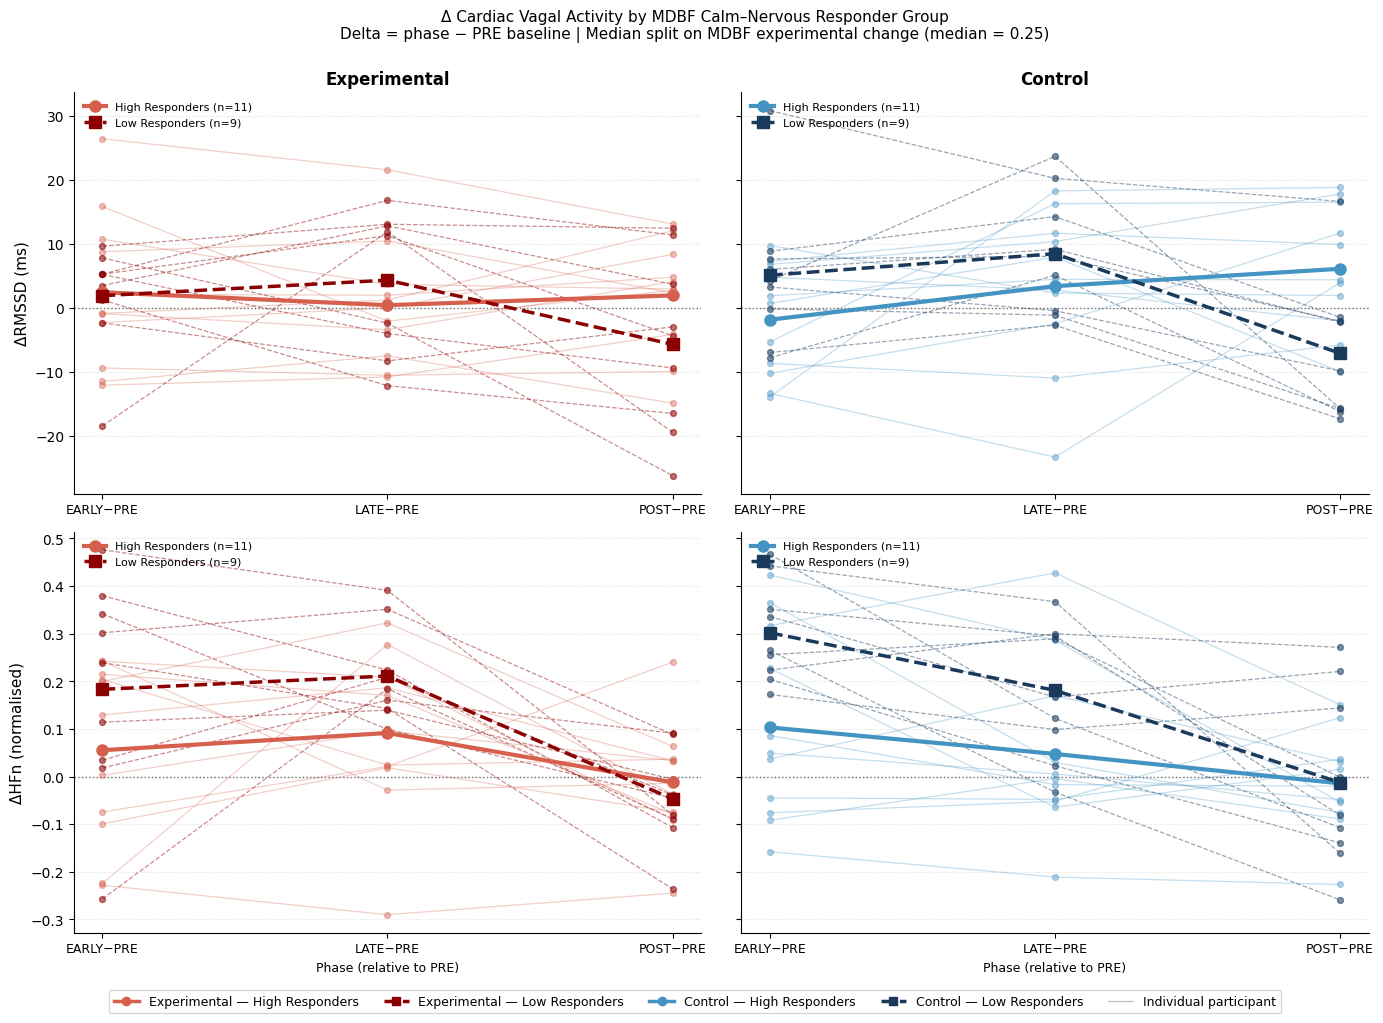


Figure saved → C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data\derivatives\group_figures\mdbf_split_delta_hrv.png


In [5]:
#mbdf delta
"""
Script 04b: MDBF median split — Delta HRV (change from PRE baseline)

For each participant: ΔRMSSD and ΔHFn at EARLY, LATE, POST
calculated as (phase value) − (PRE value) within the same condition.

This removes individual baseline differences and shows who actually
changed — which is what the MDBF responder split predicts.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import os

# ─── PATHS ────────────────────────────────────────────────────────────────────
BIDS_ROOT  = r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data"
DERIV      = os.path.join(BIDS_ROOT, "derivatives")
FIG_DIR    = os.path.join(DERIV, "group_figures")
os.makedirs(FIG_DIR, exist_ok=True)

HRV_T_FILE = os.path.join(DERIV, "hrv-analysis",
                           "task-BBSIG_per_phase_hrv-time.tsv")
HRV_F_FILE = os.path.join(DERIV, "hrv-analysis",
                           "task-BBSIG_per_phase_hrv-freq.tsv")

# ─── MDBF VALUES ──────────────────────────────────────────────────────────────
VP_CODES = [2,4,6,8,10,12,18,20,22,24,1,3,5,7,9,11,15,19,23,25]

MDBF_EXP = [0.125,-1.0,0.375,-1.625,0.625,-0.25,0.625,0.5,-0.125,0.875,
            0.0,1.0,1.125,-0.125,0.25,0.75,-0.125,0.25,0.75,0.0]

MDBF_CTRL = [0.25,0.125,0.375,0.125,1.5,0.125,0.75,0.0,0.5,0.125,
             0.0,0.625,0.5,-0.25,0.0,0.25,0.0,0.75,0.625,0.125]

median_val = np.median(MDBF_EXP)
print(f"Median MDBF Calm–Nervous change (experimental): {median_val}")

mdbf = pd.DataFrame({
    "subj_id":         [f"sub-{v:03d}" for v in VP_CODES],
    "mdbf_exp_change":  MDBF_EXP,
    "mdbf_ctrl_change": MDBF_CTRL,
    "group": ["High Responders" if m >= median_val else "Low Responders"
              for m in MDBF_EXP],
})

print(f"\n  High Responders (≥{median_val}): "
      f"{(mdbf['group']=='High Responders').sum()}")
print(f"  Low Responders  (<{median_val}):  "
      f"{(mdbf['group']=='Low Responders').sum()}")

# ─── LOAD + MERGE ─────────────────────────────────────────────────────────────
def load_hrv(path):
    df = pd.read_csv(path, sep="\t")
    df.columns = df.columns.str.strip()
    df["phase"] = df["phase"].str.lower()
    return df

hrv_t = load_hrv(HRV_T_FILE).merge(mdbf, on="subj_id", how="left")
hrv_f = load_hrv(HRV_F_FILE).merge(mdbf, on="subj_id", how="left")

# ─── COMPUTE DELTAS ───────────────────────────────────────────────────────────
def compute_deltas(df, col):
    """
    Return long-format delta values: each row = one subject × condition × phase
    Delta = phase_value − PRE_value (within same subject × condition)
    """
    wide = df[df["phase"].isin(["pre","early","late","post"])].pivot_table(
        index=["subj_id","condition","group"],
        columns="phase",
        values=col
    ).reset_index()

    rows = []
    for _, row in wide.iterrows():
        pre_val = row.get("pre", np.nan)
        if pd.isna(pre_val):
            continue
        for ph in ["early", "late", "post"]:
            ph_val = row.get(ph, np.nan)
            rows.append({
                "subj_id":   row["subj_id"],
                "condition": row["condition"],
                "group":     row["group"],
                "phase":     ph,
                "delta":     ph_val - pre_val if not pd.isna(ph_val) else np.nan,
                "pre_val":   pre_val,
                "raw_val":   ph_val,
            })

    return pd.DataFrame(rows)

delta_rmssd = compute_deltas(hrv_t, "RMSSD")
delta_hfn   = compute_deltas(hrv_f, "HFn")

print("\nDelta RMSSD (experimental) — group means:")
print(delta_rmssd[delta_rmssd["condition"]=="experimental"]
      .groupby(["group","phase"])["delta"]
      .mean().round(2).unstack())

print("\nDelta HFn (experimental) — group means:")
print(delta_hfn[delta_hfn["condition"]=="experimental"]
      .groupby(["group","phase"])["delta"]
      .mean().round(4).unstack())

# ─── PLOT SETTINGS ────────────────────────────────────────────────────────────
DELTA_PHASES  = ["early", "late", "post"]
DELTA_XLBL    = ["EARLY−PRE", "LATE−PRE", "POST−PRE"]
X_POS         = {p: i for i, p in enumerate(DELTA_PHASES)}

COLORS = {
    ("experimental", "High Responders"): "#D6604D",
    ("experimental", "Low Responders"):  "#8B0000",
    ("control",      "High Responders"): "#4393C3",
    ("control",      "Low Responders"):  "#1A3A5C",
}
LINESTYLE = {"High Responders": "-",  "Low Responders": "--"}
MARKERS   = {"High Responders": "o",  "Low Responders": "s"}
LINEWIDTH = {"High Responders": 3.0,  "Low Responders": 2.5}
ALPHA_IND = {"High Responders": 0.30, "Low Responders": 0.45}

# ─── COMBINED 2×2 FIGURE ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey="row")

fig.suptitle(
    "Δ Cardiac Vagal Activity by MDBF Calm–Nervous Responder Group\n"
    f"Delta = phase − PRE baseline | Median split on MDBF experimental change "
    f"(median = {median_val})\n",
    fontsize=11
)

MEASURES = [
    (delta_rmssd, "ΔRMSSD (ms)"),
    (delta_hfn,   "ΔHFn (normalised)"),
]

for row_i, (delta_df, ylabel) in enumerate(MEASURES):
    for col_i, condition in enumerate(["experimental", "control"]):

        ax      = axes[row_i, col_i]
        cond_df = delta_df[delta_df["condition"] == condition]

        # Zero reference line
        ax.axhline(0, color="black", lw=1.0, ls=":", alpha=0.6, zorder=1)

        for group in ["High Responders", "Low Responders"]:
            group_df = cond_df[cond_df["group"] == group]
            color    = COLORS[(condition, group)]
            ls       = LINESTYLE[group]

            # Individual spaghetti
            for subj, sub_df in group_df.groupby("subj_id"):
                pts = (sub_df[sub_df["phase"].isin(DELTA_PHASES)]
                       .assign(x=lambda d: d["phase"].map(X_POS))
                       .sort_values("x")
                       .dropna(subset=["delta"]))
                if len(pts) < 2:
                    continue
                ax.plot(pts["x"], pts["delta"],
                        color=color, lw=0.9, ls=ls,
                        alpha=ALPHA_IND[group], zorder=2)

                # Dot at each phase
                ax.scatter(pts["x"], pts["delta"],
                           color=color, s=18, alpha=ALPHA_IND[group]+0.1,
                           zorder=2)

            # Group mean line (bold)
            means = (group_df[group_df["phase"].isin(DELTA_PHASES)]
                     .groupby("phase")["delta"].mean()
                     .reset_index()
                     .assign(x=lambda d: d["phase"].map(X_POS))
                     .sort_values("x"))
            n_grp = group_df["subj_id"].nunique()
            ax.plot(means["x"], means["delta"],
                    color=color, lw=LINEWIDTH[group], ls=ls,
                    marker=MARKERS[group], ms=8, zorder=5,
                    label=f"{group} (n={n_grp})")

        ax.set_xticks(range(len(DELTA_PHASES)))
        ax.set_xticklabels(DELTA_XLBL, fontsize=9)
        ax.grid(axis="y", ls=":", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if row_i == 0:
            ax.set_title(condition.capitalize(), fontsize=12,
                         fontweight="bold")
        if col_i == 0:
            ax.set_ylabel(ylabel, fontsize=11)
        if row_i == 1:
            ax.set_xlabel("Phase (relative to PRE)", fontsize=9)

        # Per-panel legend
        ax.legend(fontsize=8, frameon=False, loc="upper left")

# Global legend
handles = [
    mlines.Line2D([], [], color=COLORS[("experimental","High Responders")],
                  lw=2.5, ls="-",  marker="o", ms=6,
                  label="Experimental — High Responders"),
    mlines.Line2D([], [], color=COLORS[("experimental","Low Responders")],
                  lw=2.5, ls="--", marker="s", ms=6,
                  label="Experimental — Low Responders"),
    mlines.Line2D([], [], color=COLORS[("control","High Responders")],
                  lw=2.5, ls="-",  marker="o", ms=6,
                  label="Control — High Responders"),
    mlines.Line2D([], [], color=COLORS[("control","Low Responders")],
                  lw=2.5, ls="--", marker="s", ms=6,
                  label="Control — Low Responders"),
    mlines.Line2D([], [], color="grey", lw=0.9, alpha=0.5,
                  label="Individual participant"),
]
fig.legend(handles=handles, loc="lower center",
           ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
out = os.path.join(FIG_DIR, "mdbf_split_delta_hrv.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"\nFigure saved → {out}")

ASC median (experimental): 0.20
MDBF median:               0.250


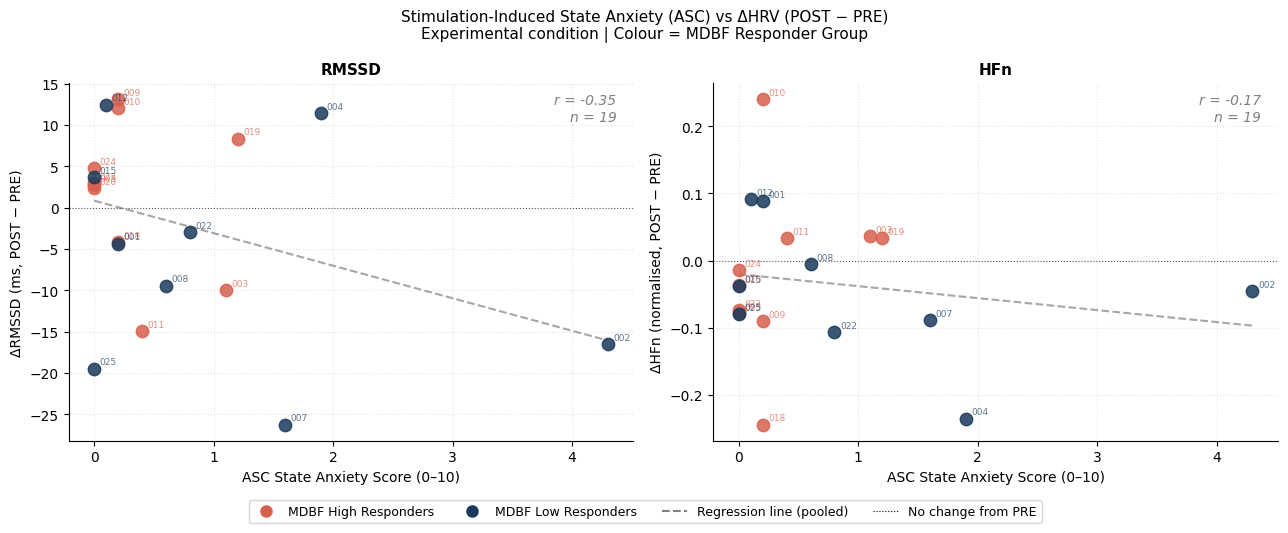

Saved → C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data\derivatives\group_figures\asc_anxiety_vs_delta_hrv.png


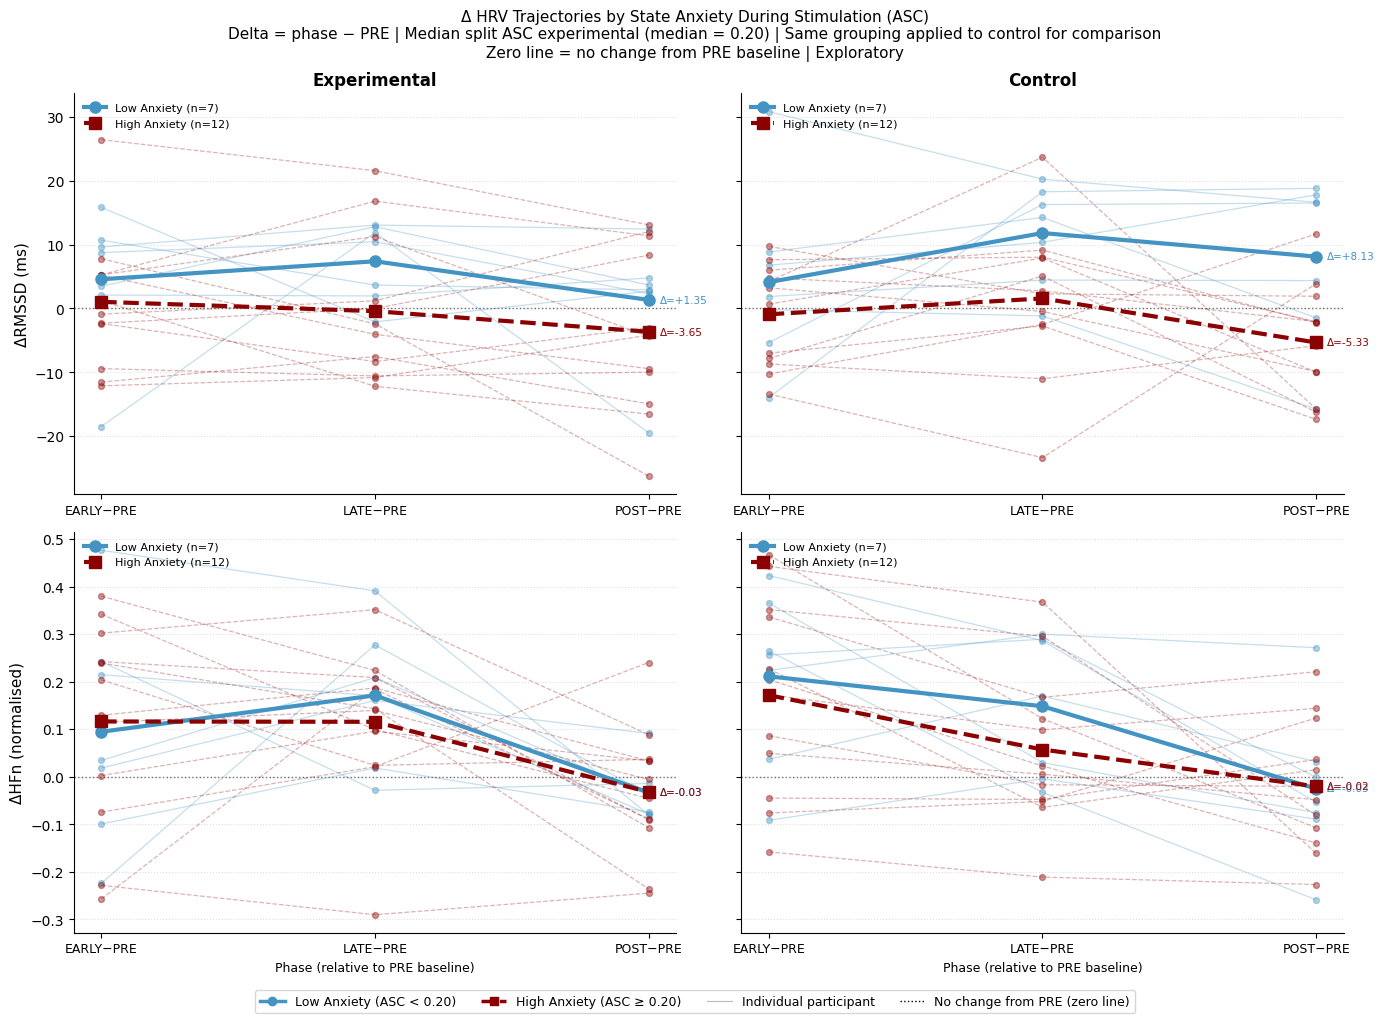

Saved → C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data\derivatives\group_figures\asc_anxiety_delta_hrv_trajectories.png


In [6]:
#ASC delta
"""
Script 06b: ASC State Anxiety × Delta HRV

Same two figures as script 06 but using ΔHRV (phase − PRE baseline)
instead of absolute values.

Figure 1 — Scatter: ASC anxiety vs ΔHRV (POST−PRE)
  Shows whether anxious participants had smaller HRV increase after stimulation.

Figure 2 — Delta trajectories: ΔRMSSD and ΔHFn across EARLY, LATE, POST
  Split by HIGH vs LOW ASC anxiety group (median split on ASC_EXP)
  2 rows × 2 cols: RMSSD/HFn × Experimental/Control
  Zero line = no change from PRE baseline
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import os

# ─── PATHS ────────────────────────────────────────────────────────────────────
BIDS_ROOT  = r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data"
DERIV      = os.path.join(BIDS_ROOT, "derivatives")
FIG_DIR    = os.path.join(DERIV, "group_figures")
os.makedirs(FIG_DIR, exist_ok=True)

HRV_T_FILE = os.path.join(DERIV, "hrv-analysis",
                           "task-BBSIG_per_phase_hrv-time.tsv")
HRV_F_FILE = os.path.join(DERIV, "hrv-analysis",
                           "task-BBSIG_per_phase_hrv-freq.tsv")

# ─── HARDCODED DATA ───────────────────────────────────────────────────────────
VP_CODES = [2,4,6,8,10,12,18,20,22,24,1,3,5,7,9,11,15,19,23,25]

MDBF_EXP = [0.125,-1.0,0.375,-1.625,0.625,-0.25,0.625,0.5,-0.125,0.875,
            0.0,1.0,1.125,-0.125,0.25,0.75,-0.125,0.25,0.75,0.0]

ASC_EXP  = [4.3,1.9,np.nan,0.6,0.2,0.1,0.2,0.0,0.8,0.0,0.2,
            1.1,0.0,1.6,0.2,0.4,0.0,1.2,0.0,0.0]

median_mdbf = np.median(MDBF_EXP)
MDBF_GROUP  = ["High Responders" if m >= median_mdbf else "Low Responders"
               for m in MDBF_EXP]

asc_valid  = [v for v in ASC_EXP if not np.isnan(v)]
median_asc = np.median(asc_valid)
ASC_GROUP  = ["High Anxiety" if (not np.isnan(v) and v >= median_asc)
              else ("Low Anxiety" if not np.isnan(v) else np.nan)
              for v in ASC_EXP]

print(f"ASC median (experimental): {median_asc:.2f}")
print(f"MDBF median:               {median_mdbf:.3f}")

# ─── LOAD + MERGE ─────────────────────────────────────────────────────────────
def load_hrv(path):
    df = pd.read_csv(path, sep="\t")
    df.columns = df.columns.str.strip()
    df["phase"] = df["phase"].str.lower()
    return df

lookup = pd.DataFrame({
    "subj_id":    [f"sub-{v:03d}" for v in VP_CODES],
    "asc_exp":     ASC_EXP,
    "mdbf_group":  MDBF_GROUP,
    "asc_group":   ASC_GROUP,
})

hrv_t = load_hrv(HRV_T_FILE).merge(lookup, on="subj_id", how="left")
hrv_f = load_hrv(HRV_F_FILE).merge(lookup, on="subj_id", how="left")

# ─── COMPUTE DELTAS ───────────────────────────────────────────────────────────
def compute_deltas(df, col):
    """Delta = phase − PRE for each subject × condition."""
    wide = df[df["phase"].isin(["pre","early","late","post"])].pivot_table(
        index=["subj_id","condition","asc_exp","mdbf_group","asc_group"],
        columns="phase",
        values=col
    ).reset_index()

    rows = []
    for _, row in wide.iterrows():
        pre_val = row.get("pre", np.nan)
        if pd.isna(pre_val):
            continue
        for ph in ["early", "late", "post"]:
            ph_val = row.get(ph, np.nan)
            rows.append({
                "subj_id":    row["subj_id"],
                "condition":  row["condition"],
                "asc_exp":    row["asc_exp"],
                "mdbf_group": row["mdbf_group"],
                "asc_group":  row["asc_group"],
                "phase":      ph,
                "delta":      ph_val - pre_val if not pd.isna(ph_val) else np.nan,
            })
    return pd.DataFrame(rows)

delta_rmssd = compute_deltas(hrv_t, "RMSSD")
delta_hfn   = compute_deltas(hrv_f, "HFn")

# POST-PRE change specifically for scatter plot
def get_post_pre(delta_df):
    return delta_df[delta_df["phase"] == "post"][
        ["subj_id","condition","asc_exp","mdbf_group","asc_group","delta"]
    ].rename(columns={"delta": "post_pre_change"})

rmssd_post = get_post_pre(delta_rmssd)
hfn_post   = get_post_pre(delta_hfn)

# ─── COLOURS ──────────────────────────────────────────────────────────────────
MDBF_COLORS = {"High Responders": "#D6604D", "Low Responders": "#1A3A5C"}
ASC_COLORS  = {"High Anxiety":    "#8B0000", "Low Anxiety":    "#4393C3"}

DELTA_PHASES = ["early", "late", "post"]
DELTA_XLBL   = ["EARLY−PRE", "LATE−PRE", "POST−PRE"]
X_POS        = {p: i for i, p in enumerate(DELTA_PHASES)}

# ─── FIGURE 1: Scatter — ASC × ΔHRV (POST−PRE), experimental only ────────────
fig1, axes1 = plt.subplots(1, 2, figsize=(13, 5))

fig1.suptitle(
    "Stimulation-Induced State Anxiety (ASC) vs ΔHRV (POST − PRE)\n"
    "Experimental condition | Colour = MDBF Responder Group",
    fontsize=11
)

for ax, df_post, ylabel, title in [
    (axes1[0],
     rmssd_post[rmssd_post["condition"]=="experimental"],
     "ΔRMSSD (ms, POST − PRE)", "RMSSD"),
    (axes1[1],
     hfn_post[hfn_post["condition"]=="experimental"],
     "ΔHFn (normalised, POST − PRE)", "HFn"),
]:
    for grp in ["High Responders", "Low Responders"]:
        sub = df_post[df_post["mdbf_group"] == grp].dropna(
            subset=["asc_exp","post_pre_change"])
        ax.scatter(sub["asc_exp"], sub["post_pre_change"],
                   color=MDBF_COLORS[grp], s=80, alpha=0.85,
                   label=grp, zorder=3)

        # Label each point with subject number
        for _, row in sub.iterrows():
            ax.annotate(
                row["subj_id"].replace("sub-",""),
                (row["asc_exp"], row["post_pre_change"]),
                textcoords="offset points", xytext=(4, 3),
                fontsize=6.5, color=MDBF_COLORS[grp], alpha=0.7
            )

    # Regression line (pooled, experimental only)
    valid = df_post.dropna(subset=["asc_exp","post_pre_change"])
    if len(valid) > 3:
        m, b   = np.polyfit(valid["asc_exp"], valid["post_pre_change"], 1)
        x_line = np.linspace(valid["asc_exp"].min(),
                             valid["asc_exp"].max(), 100)
        ax.plot(x_line, m*x_line + b,
                color="grey", lw=1.5, ls="--", alpha=0.7,
                label="Regression (pooled)")
        r = np.corrcoef(valid["asc_exp"], valid["post_pre_change"])[0,1]
        n_valid = len(valid)
        ax.text(0.97, 0.97,
                f"r = {r:.2f}\nn = {n_valid}",
                ha="right", va="top", transform=ax.transAxes,
                fontsize=10, color="grey", style="italic")

    ax.axhline(0, color="black", lw=0.8, ls=":", alpha=0.6,
               label="No change from PRE")
    ax.set_xlabel("ASC State Anxiety Score (0–10)", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(ls=":", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles1 = [
    mlines.Line2D([], [], marker="o", color=MDBF_COLORS["High Responders"],
                  lw=0, ms=8, label="MDBF High Responders"),
    mlines.Line2D([], [], marker="o", color=MDBF_COLORS["Low Responders"],
                  lw=0, ms=8, label="MDBF Low Responders"),
    mlines.Line2D([], [], color="grey", lw=1.5, ls="--",
                  label="Regression line (pooled)"),
    mlines.Line2D([], [], color="black", lw=0.8, ls=":",
                  label="No change from PRE"),
]
fig1.legend(handles=handles1, loc="lower center",
            ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
out1 = os.path.join(FIG_DIR, "asc_anxiety_vs_delta_hrv.png")
plt.savefig(out1, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out1}")

# ─── FIGURE 2: Delta HRV trajectories by ASC group ───────────────────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10), sharey="row")

fig2.suptitle(
    "Δ HRV Trajectories by State Anxiety During Stimulation (ASC)\n"
    f"Delta = phase − PRE | Median split ASC experimental "
    f"(median = {median_asc:.2f}) | "
    "Same grouping applied to control for comparison\n"
    "Zero line = no change from PRE baseline | Exploratory",
    fontsize=11
)

MEASURES = [
    (delta_rmssd, "ΔRMSSD (ms)"),
    (delta_hfn,   "ΔHFn (normalised)"),
]

for row_i, (delta_df, ylabel) in enumerate(MEASURES):
    for col_i, condition in enumerate(["experimental", "control"]):

        ax      = axes2[row_i, col_i]
        cond_df = delta_df[delta_df["condition"] == condition]

        # Zero reference
        ax.axhline(0, color="black", lw=1.0, ls=":", alpha=0.6, zorder=1)

        for grp in ["Low Anxiety", "High Anxiety"]:
            group_df = cond_df[cond_df["asc_group"] == grp]
            color    = ASC_COLORS[grp]
            ls       = "-" if grp == "Low Anxiety" else "--"
            marker   = "o" if grp == "Low Anxiety" else "s"

            # Individual spaghetti
            for subj, sub_df in group_df.groupby("subj_id"):
                pts = (sub_df[sub_df["phase"].isin(DELTA_PHASES)]
                       .assign(x=lambda d: d["phase"].map(X_POS))
                       .sort_values("x")
                       .dropna(subset=["delta"]))
                if len(pts) < 1:
                    continue
                ax.plot(pts["x"], pts["delta"],
                        color=color, lw=0.9, ls=ls,
                        alpha=0.30, zorder=2)
                ax.scatter(pts["x"], pts["delta"],
                           color=color, s=18,
                           alpha=0.40, zorder=2)

            # Group mean
            means = (group_df[group_df["phase"].isin(DELTA_PHASES)]
                     .groupby("phase")["delta"].mean()
                     .reset_index()
                     .assign(x=lambda d: d["phase"].map(X_POS))
                     .sort_values("x"))
            n_grp = group_df["subj_id"].nunique()
            ax.plot(means["x"], means["delta"],
                    color=color, lw=3.0, ls=ls,
                    marker=marker, ms=8, zorder=5,
                    label=f"{grp} (n={n_grp})")

            # Annotate POST-PRE mean difference
            post_mean = means[means["phase"]=="post"]["delta"].values
            if len(post_mean) > 0 and not np.isnan(post_mean[0]):
                ax.annotate(
                    f"Δ={post_mean[0]:+.2f}",
                    xy=(X_POS["post"], post_mean[0]),
                    xytext=(8, 0), textcoords="offset points",
                    fontsize=7.5, color=color, va="center"
                )

        ax.set_xticks(range(len(DELTA_PHASES)))
        ax.set_xticklabels(DELTA_XLBL, fontsize=9)
        ax.grid(axis="y", ls=":", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if row_i == 0:
            ax.set_title(condition.capitalize(), fontsize=12,
                         fontweight="bold")
        if col_i == 0:
            ax.set_ylabel(ylabel, fontsize=11)
        if row_i == 1:
            ax.set_xlabel("Phase (relative to PRE baseline)", fontsize=9)

        ax.legend(fontsize=8, frameon=False, loc="upper left")

handles2 = [
    mlines.Line2D([], [], color=ASC_COLORS["Low Anxiety"],
                  lw=2.5, ls="-",  marker="o", ms=6,
                  label=f"Low Anxiety (ASC < {median_asc:.2f})"),
    mlines.Line2D([], [], color=ASC_COLORS["High Anxiety"],
                  lw=2.5, ls="--", marker="s", ms=6,
                  label=f"High Anxiety (ASC ≥ {median_asc:.2f})"),
    mlines.Line2D([], [], color="grey", lw=0.9, alpha=0.5,
                  label="Individual participant"),
    mlines.Line2D([], [], color="black", lw=1.0, ls=":",
                  label="No change from PRE (zero line)"),
]
fig2.legend(handles=handles2, loc="lower center",
            ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
out2 = os.path.join(FIG_DIR, "asc_anxiety_delta_hrv_trajectories.png")
plt.savefig(out2, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out2}")

Output directory: C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data\derivatives\group_figures_revised
Data loaders ready.
  Total windows: 2520
  Saved -> task-BBSIG_hrv_sliding_revised.tsv
Phase-level data loaded.

FIGURE 1 — sliding window grid
  Saved -> Figure1_sliding_grid_n15.png

FIGURE 2 — combined trajectory grid (3 columns x 2 rows)
  Saved -> Figure2_trajectory_grid_n15.png

Individual trajectory files...
  Saved -> traj_RMSSD_n15_means.png
  Saved -> traj_RMSSD_n15_indiv.png
  Saved -> traj_HFn_n15_means.png
  Saved -> traj_HFn_n15_indiv.png
  Saved -> traj_HR_n15_means.png
  Saved -> traj_HR_n15_indiv.png
  Saved -> traj_EDA_n17_means.png
  Saved -> traj_EDA_n17_indiv.png
  Saved -> traj_EDA_delta_n17_means.png
  Saved -> traj_EDA_delta_n17_indiv.png
  Saved -> traj_TEMP_abs_n15_means.png
  Saved -> traj_TEMP_abs_n15_indiv.png
  Saved -> traj_TEMP_delta_n15_means.png
  Saved -> traj_TEMP_delta_n15_indiv.png
  Saved -> traj_BF_abs_n15_means.png
  Saved -> traj_BF_abs_n

OSError: [Errno 22] Invalid argument: 'C:\\Users\\alisa\\OneDrive\\Desktop\\HRV_Biotrace\\bids_data\\derivatives\\group_figures_revised\\Figure3_delta_grid_n15.png'

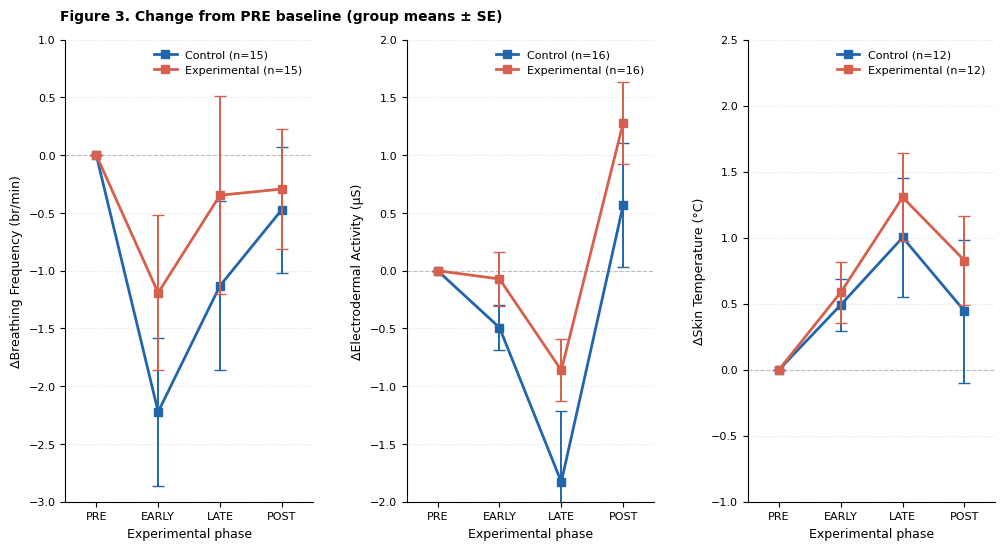

In [28]:
# group trajectories + sliding windows — CORRECTED
import numpy as np
import pandas as pd
import neurokit2 as nk
import json, math
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
BIDS_ROOT = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")
DERIV     = BIDS_ROOT / "derivatives"
FIG_DIR   = DERIV / "group_figures_revised"
FIG_DIR.mkdir(exist_ok=True)

TASK     = "BBSIG"
WINDOW_S = 60
STEP_S   = 30

ALL_PARTICIPANTS = [
    "001","002","003","004","005","006","007","008","009","010",
    "011","012","015","018","019","020","021","022","023","024","025"
]
SESSION_IDS = ["01", "02"]

EXCL_ECG_N20 = {"sub-021"}
EXCL_ECG_N15 = {"sub-021","sub-010","sub-002","sub-007","sub-020","sub-023"}
EXCL_RSP     = {"sub-021","sub-010","sub-002","sub-007","sub-020","sub-023"}
EXCL_EDA     = {"sub-021","sub-003","sub-005","sub-011"}
EXCL_TEMP    = {"sub-021", "sub-001","sub-008","sub-012","sub-022","sub-025"}

COLORS = {"control": "#2166AC", "experimental": "#D6604D"}

PHASES      = ["pre", "early", "late", "post"]
PHASE_LBL   = {"pre":"PRE","early":"EARLY","late":"LATE","post":"POST"}
PHASE_SHADE = {
    "pre":   "#AEC6E8",
    "early": "#B2E2B2",
    "late":  "#D8B4E8",
    "post":  "#FDDBA8",
}

#manual y axis
# Figure 1 — sliding window timecourses
YLIM_FIG1 = {
    "RMSSD": (0,   80),
    "HFn":   (0,  1.0),
    "HR":    (55,   95),
    "BF":    (5,    25),
    "EDA":   (0,    12),
    "TEMP":  (27,   37),
}

# Figure 2 — group mean trajectories
YLIM_FIG2 = {
    "RMSSD": (30,   46),
    "HFn":   (0.2,  0.55),
    "HR":    (65,   85),
    "BF":    (12,   18),
    "EDA":   (1,    7),
    "TEMP":  (32,   35),
}

# Figure 3 — delta (change from PRE) trajectories
YLIM_FIG3 = {
    "BF":    (-3.0, 1.0),
    "EDA":   (-2.0, 2.0),
    "TEMP":  (-1.0, 2.5),
}

# Fallback used by standalone plot_trajectories calls (individual files)
YLIM = {
    "RMSSD": (20,   50),
    "HF":    (0,    250),
    "LnHF":  (8,    12),
    "HFn":   (0.1,  0.6),
    "HR":    (60,   85),
    "BF":    (10,   20),
    "EDA":   (0,    8),
    "TEMP":  (-0.50, 2),
}


# SHARED STYLE CONSTANTS
# All three figures use these values so lines, fonts and markers are identical.
LINE_LW        = 2.0          # line width for group mean lines
CI_ALPHA       = 0.15         # shading opacity for 95% CI (Fig 1)
ERROR_CAP      = 4            # errorbar cap size in points (Fig 2 & 3)
ERROR_LW       = 1.4          # errorbar line width
MARKER_SIZE    = 6            # marker size for trajectory dots
LEGEND_FS      = 8            # legend font size (all figures)
YLABEL_FS      = 9            # y-axis label font size (all figures)
XLABEL_FS      = 9            # x-axis label font size (all figures)
TICK_FS        = 8            # tick label font size (all figures)
PANEL_TITLE_FS = 10           # panel/figure title font size (all figures)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size":   11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

print(f"Output directory: {FIG_DIR}")

# CELL 2 — Low-level data loaders

def load_rr(subj_id, ses_id):
    base = f"sub-{subj_id}_ses-{ses_id}_task-{TASK}_physio"
    for p in [
        DERIV/f"ecg-preproc/sub-{subj_id}/ses-{ses_id}/{base}_ecg-preproc.json",
        DERIV/f"ecg-preproc/sub-{subj_id}/ses-{ses_id}/beh/{base}_ecg-preproc.json",
    ]:
        if p.exists():
            with open(p) as f:
                d = json.load(f)
            rr_s = d.get("rr_s", {})
            arr  = rr_s.get("RR_s_corrected") or rr_s.get("RR_s_original")
            if arr:
                rr_s_arr  = np.asarray(arr, dtype=float)
                return rr_s_arr * 1000.0, np.cumsum(rr_s_arr)
    return None, None


def load_phases(subj_id, ses_id):
    base = f"sub-{subj_id}_ses-{ses_id}_task-{TASK}_physio"
    p    = DERIV/f"phases/sub-{subj_id}/ses-{ses_id}/{base}_phases.json"
    if not p.exists():
        return None, None
    with open(p) as f:
        d = json.load(f)
    return d["phases"], d.get("condition", "unknown")


def stim_start_s(phases):
    return phases["early"]["start"] - 30


def snap(t):
    return int(round(t / STEP_S)) * STEP_S


def read_first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None


def compute_rmssd(rri_ms):
    return float(np.sqrt(np.mean(np.diff(rri_ms)**2))) if len(rri_ms) >= 5 else np.nan


def compute_hf_root_ms(rri_time_s):
    try:
        h = nk.hrv_frequency(peaks=rri_time_s, sampling_rate=1,
                              hf=(0.15,0.4), show=False)
        return float(np.sqrt(float(h["HRV_HF"].values[0])) * 1000.0)
    except Exception:
        return np.nan


def compute_hf_root_log(rri_time_s):
    v = compute_hf_root_ms(rri_time_s)
    return math.log(v) if (v is not None and v > 0) else np.nan


def compute_hfn(rri_time_s):
    try:
        h  = nk.hrv_frequency(peaks=rri_time_s, sampling_rate=1,
                               hf=(0.15,0.4), lf=(0.04,0.15), show=False)
        hf = float(h["HRV_HF"].values[0])
        lf = float(h["HRV_LF"].values[0])
        return hf / (lf + hf) if (lf + hf) > 0 else np.nan
    except Exception:
        return np.nan


def ci95(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[~np.isnan(vals)]
    if len(vals) < 2:
        return np.nan, np.nan, np.nan
    se = stats.sem(vals)
    h  = se * stats.t.ppf(0.975, df=len(vals)-1)
    m  = float(vals.mean())
    return m, m-h, m+h


print("Data loaders ready.")


# =============================================================================
# CELL 3 — Compute HRV sliding windows
# =============================================================================

hrv_rows    = []
phase_bounds = {ph: [] for ph in PHASES}

for subj_id in ALL_PARTICIPANTS:
    for ses_id in SESSION_IDS:
        rri, rri_time_s = load_rr(subj_id, ses_id)
        if rri is None:
            continue
        phases, condition = load_phases(subj_id, ses_id)
        if phases is None:
            continue
        t0 = stim_start_s(phases)
        for ph in PHASES:
            if ph in phases:
                p = phases[ph]
                phase_bounds[ph].append((p["start"]-t0, p["end"]-t0))

        win_ms  = WINDOW_S * 1000
        step_ms = STEP_S   * 1000
        t_abs   = rri_time_s[0] * 1000.0

        while t_abs + win_ms <= rri_time_s[-1] * 1000.0:
            t_rel = snap(t_abs/1000.0 + WINDOW_S/2 - t0)
            mask  = ((rri_time_s*1000.0 >= t_abs) &
                     (rri_time_s*1000.0 <  t_abs + win_ms))
            rri_w = rri[mask]
            t_w_s = rri_time_s[mask]
            if len(rri_w) >= 10:
                hrv_rows.append({
                    "subj_id":   f"sub-{subj_id}",
                    "ses_id":    f"ses-{ses_id}",
                    "condition": condition,
                    "time_rel":  t_rel,
                    "RMSSD":     compute_rmssd(rri_w),
                    "HF":        compute_hf_root_ms(t_w_s),
                    "HFn":       compute_hfn(t_w_s),
                    "LnHF":      compute_hf_root_log(t_w_s),
                    "HR":        float(60000 / np.mean(rri_w)),
                })
            t_abs += step_ms

df_hrv = pd.DataFrame(hrv_rows)
print(f"  Total windows: {len(df_hrv)}")
out = DERIV/"hrv-analysis"/f"task-{TASK}_hrv_sliding_revised.tsv"
df_hrv.to_csv(out, sep="\t", index=False)
print(f"  Saved -> {out.name}")


# =============================================================================
# CELL 4 — Load phase-level data
# =============================================================================

hrv_time_path = read_first_existing([
    DERIV/"hrv-analysis"/"task-BBSIG_per_phase_hrv-time.tsv",
    DERIV/"hrv-analysis"/"task-BBSIG_per_phase_hrv-time_trimmed.tsv",
    DERIV/"hrv-analysis"/"task-BBSIG_per_phase_hrv-time_trimmed_clean.tsv",
])
hrv_freq_path = read_first_existing([
    DERIV/"hrv-analysis"/"task-BBSIG_per_phase_hrv-freq.tsv",
    DERIV/"hrv-analysis"/"task-BBSIG_per_phase_hrv-freq_trimmed.tsv",
    DERIV/"hrv-analysis"/"task-BBSIG_per_phase_hrv-freq_trimmed_clean.tsv",
])

hrv_time  = pd.read_csv(hrv_time_path, sep="\t")
hrv_freq  = pd.read_csv(hrv_freq_path, sep="\t")
hrv_phase = hrv_time.merge(hrv_freq,
                            on=["subj_id","ses_id","condition","phase"],
                            how="left", suffixes=("","_freq"))

if "HF" in hrv_phase.columns:
    hrv_phase["HF_root_ms"]  = hrv_phase["HF"].apply(
        lambda x: np.sqrt(x*1_000_000) if pd.notna(x) else np.nan)
    hrv_phase["HF_root_log"] = np.log(hrv_phase["HF_root_ms"])
if "LnHF"  in hrv_phase.columns:
    hrv_phase["LnHF_ms2"] = hrv_phase["LnHF"] + math.log(1_000_000)
if "RMSSD" in hrv_phase.columns:
    hrv_phase["RMSSD_log"] = np.log(hrv_phase["RMSSD"] + 1)
if "MeanHR" in hrv_phase.columns:
    hrv_phase["HR_log"] = np.log(hrv_phase["MeanHR"] + 2)

eda_src    = read_first_existing([
    DERIV/"eda-analysis"/"task-BBSIG_eda-temp-bf_per_phase_final.tsv",
    DERIV/"eda-analysis"/"task-BBSIG_eda-temp-bf_per_phase_clean.tsv",
    DERIV/"eda-analysis"/"task-BBSIG_eda-temp-bf_per_phase.tsv",
])
df_eda_src = pd.read_csv(eda_src, sep="\t")
bf_src     = DERIV/"bf-analysis"/f"task-{TASK}_per_phase_bf.tsv"
df_bf_src  = pd.read_csv(bf_src, sep="\t")

eda_col  = next((c for c in df_eda_src.columns
                 if "eda"  in c.lower() and "log" not in c.lower()
                 and c not in ("subj_id","ses_id","condition","phase")), None)
temp_col = next((c for c in df_eda_src.columns
                 if "temp" in c.lower() and "log" not in c.lower()
                 and c not in ("subj_id","ses_id","condition","phase")), None)
bf_col   = next((c for c in df_bf_src.columns
                 if "bf"   in c.lower() and "bpm" in c.lower()
                 and c not in ("subj_id","ses_id","condition","phase")), None)


def make_phase_tc(src_df, val_col):
    rows = []
    for subj_id in ALL_PARTICIPANTS:
        for ses_id in SESSION_IDS:
            phases, condition = load_phases(subj_id, ses_id)
            if phases is None:
                continue
            t0  = stim_start_s(phases)
            vp  = f"sub-{subj_id}"
            ses = f"ses-{ses_id}"
            sub = src_df[(src_df["subj_id"]==vp) & (src_df["ses_id"]==ses)]
            if sub.empty:
                continue
            for ph_name, p in phases.items():
                t_rel  = snap((p["end"] if ph_name=="post" else p["start"]) - t0)
                row_ph = sub[sub["phase"]==ph_name]
                if row_ph.empty:
                    continue
                val = row_ph[val_col].values[0]
                rows.append({
                    "subj_id":   vp,
                    "ses_id":    ses,
                    "condition": condition,
                    "time_rel":  t_rel,
                    "phase":     ph_name,
                    "value":     float(val) if not pd.isna(val) else np.nan,
                })
    return pd.DataFrame(rows)


df_eda  = make_phase_tc(df_eda_src, eda_col)  if eda_col  else None
df_temp = make_phase_tc(df_eda_src, temp_col) if temp_col else None
df_bf   = make_phase_tc(df_bf_src,  bf_col if bf_col else "BF_bpm")
print("Phase-level data loaded.")


# =============================================================================
# CELL 5 — Phase bounds
# =============================================================================

avg_bounds = {
    ph: (np.mean([b[0] for b in v]), np.mean([b[1] for b in v]))
    for ph, v in phase_bounds.items() if v
}
XMIN = -200
XMAX = max(avg_bounds["post"][1]+30, 1400)


# =============================================================================
# CELL 6 — Plotting helpers
# =============================================================================

def ci_timecourse(df, col, condition, excl_subj=None):
    d = df[df["condition"]==condition].copy()
    if excl_subj:
        d = d[~d["subj_id"].isin(excl_subj)]
    col_use = col if col in d.columns else "value"
    d = d.dropna(subset=[col_use])
    per_subj = d.groupby(["subj_id","time_rel"])[col_use].mean().reset_index()
    times, means, los, his = [], [], [], []
    for t, grp in per_subj.groupby("time_rel"):
        m, lo, hi = ci95(grp[col_use].values)
        if not np.isnan(m):
            times.append(t); means.append(m); los.append(lo); his.append(hi)
    return np.array(times), np.array(means), np.array(los), np.array(his)


def count_n(df, condition, excl_subj=None):
    d = df[df["condition"]==condition]
    if excl_subj:
        d = d[~d["subj_id"].isin(excl_subj)]
    return d["subj_id"].nunique()


def resolve_ylim(measure_key, data_lo, data_hi):
    ymin_cfg, ymax_cfg = YLIM.get(measure_key, (None, None))
    ymin = ymin_cfg if ymin_cfg is not None else (
        data_lo - abs(data_lo)*0.08 if data_lo < 0 else max(0, data_lo*0.92))
    ymax = ymax_cfg if ymax_cfg is not None else (
        data_hi*1.08 if data_hi > 0 else data_hi*0.92)
    return ymin, ymax


def _draw_sliding_panel(ax, df, col, measure_key, ylabel,
                         excl_subj=None, show_xlabel=False,
                         legend_loc="upper right"):
    """Draw one sliding-window timecourse into an existing Axes.
    Uses YLIM_FIG1 for axis limits and shared style constants for consistency."""
    data_lo, data_hi = np.inf, -np.inf
    plotted = False

    ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.4, zorder=1,
               label="Stim onset (t = 0)")

    for condition, color in COLORS.items():
        t, m, lo, hi = ci_timecourse(df, col, condition, excl_subj)
        if len(t) == 0:
            continue
        n = count_n(df, condition, excl_subj)
        ax.plot(t, m, color=color, lw=LINE_LW, zorder=3,
                label=f"{condition.capitalize()} (n={n})")
        ax.fill_between(t, lo, hi, color=color, alpha=CI_ALPHA, zorder=2)
        if len(hi): data_hi = max(data_hi, float(np.nanmax(hi)))
        if len(lo): data_lo = min(data_lo, float(np.nanmin(lo)))
        plotted = True

    if not plotted:
        return False

    # Phase shading + labels
    for ph, (s, e) in avg_bounds.items():
        ax.axvspan(s, e, color=PHASE_SHADE[ph], alpha=0.30, zorder=0)
        ax.text((s+e)/2, 1.01, PHASE_LBL[ph],
                ha="center", va="bottom", fontsize=TICK_FS,
                color="grey", style="italic",
                transform=ax.get_xaxis_transform())

    ax.set_xlim(XMIN, XMAX)
    xticks = np.arange(-200, int(np.ceil(XMAX/200.0)*200)+1, 200)
    ax.set_xticks(xticks)
    ax.tick_params(axis="both", labelsize=TICK_FS)

    if not show_xlabel:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Time relative to stimulation start (s)", fontsize=XLABEL_FS)

    # Use YLIM_FIG1 first; fall back to data-driven resolve_ylim
    if measure_key in YLIM_FIG1:
        ymin, ymax = YLIM_FIG1[measure_key]
    else:
        ymin, ymax = resolve_ylim(measure_key, data_lo, data_hi)
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel(ylabel, fontsize=YLABEL_FS)
    ax.legend(fontsize=LEGEND_FS, frameon=False, loc=legend_loc)
    ax.grid(axis="y", ls=":", alpha=0.35)
    return True

# CELL 7 — Figure 1: all sliding panels in one grid

def plot_sliding_grid(panel_specs, fname, title=""):
    n = len(panel_specs)
    fig, axes = plt.subplots(
        n, 1,
        figsize=(13, n * 2.8),          # 2.8 in per panel
        gridspec_kw={"hspace": 0.08},   # tight gap between panels
    )
    if n == 1:
        axes = [axes]

    for i, (ax, spec) in enumerate(zip(axes, panel_specs)):
        _draw_sliding_panel(
            ax          = ax,
            df          = spec["df"],
            col         = spec["col"],
            measure_key = spec["measure_key"],
            ylabel      = spec["ylabel"],
            excl_subj   = spec.get("excl_subj"),
            show_xlabel = (i == n-1),   # only bottom panel gets x-axis label
            legend_loc  = spec.get("legend_loc", "upper right"),
        )
        # Place the figure title directly above the first panel, not at fig level
        if i == 0 and title:
            ax.set_title(title, fontsize=10, fontweight="bold", pad=14)

    plt.tight_layout()
    plt.savefig(FIG_DIR/fname, dpi=200, bbox_inches="tight")
    plt.close()
    print(f"  Saved -> {fname}")


print("\n" + "="*60)
print("FIGURE 1 — sliding window grid")
print("="*60)

panels_n15 = [
    dict(df=df_hrv,  col="RMSSD", measure_key="RMSSD",
         ylabel="Root Mean Square of\nSuccessive Differences (ms)",
         excl_subj=EXCL_ECG_N15),
    dict(df=df_hrv,  col="HFn",   measure_key="HFn",
         ylabel="Normalised High-\nFrequency Power (HFn)",
         excl_subj=EXCL_RSP),
    dict(df=df_hrv,  col="HR",    measure_key="HR",
         ylabel="Heart Rate (bpm)",
         excl_subj=EXCL_ECG_N15),
    dict(df=df_bf,   col="value", measure_key="BF",
         ylabel="Breathing Frequency (br/min)",
         excl_subj=EXCL_RSP),
    dict(df=df_eda,  col="value", measure_key="EDA",
         ylabel="Electrodermal Activity (µS)",
         excl_subj=EXCL_EDA),
    dict(df=df_temp, col="value", measure_key="TEMP",
         ylabel="Skin Temperature (°C)",
         excl_subj=EXCL_TEMP),
]

plot_sliding_grid(
    panels_n15,
    fname  = "Figure1_sliding_grid_n15.png",
    title  = "Figure 1. Sliding window time-courses",
)


# =============================================================================
# CELL 8 — Figure 2: trajectory figures (means + indiv)
# =============================================================================

def make_long_complete(data, metric_col, excl_set):
    df = data[~data["subj_id"].isin(excl_set)].copy()
    df = df.dropna(subset=[metric_col])
    complete_ids = (df.groupby("subj_id").size()
                    .reset_index(name="n")
                    .query("n == 8")["subj_id"].tolist())
    out = df[df["subj_id"].isin(complete_ids)].copy()
    out["phase"]     = pd.Categorical(out["phase"], categories=PHASES, ordered=True)
    out["condition"] = out["condition"].astype("category")
    return out


def plot_trajectories(df, col, measure_key, ylabel, title_base,
                      fname_base, excl_subj=None, delta_baseline=False,
                      fig_width=None):
    col_use = col if col in df.columns else "value"
    data    = df[~df["subj_id"].isin(excl_subj or set())].copy()
    data    = data.dropna(subset=[col_use])
    data["phase"] = pd.Categorical(data["phase"], categories=PHASES, ordered=True)

    if delta_baseline:
        # ── CORRECTED: group by (subj_id, ses_id) ─────────────────────────
        pre_mean = (
            data[data["phase"] == "pre"]
            .groupby(["subj_id", "ses_id"])[col_use]
            .mean()
            .rename("pre_mean")
            .reset_index()
        )
        data = data.merge(pre_mean, on=["subj_id", "ses_id"], how="left")
        data[col_use] = data[col_use] - data["pre_mean"]
        data = data.drop(columns=["pre_mean"])
        # ──────────────────────────────────────────────────────────────────

    suffix = " (Δ from PRE)" if delta_baseline else ""
    xi    = [0, 1, 2, 3]
    xlbls = ["PRE", "EARLY", "LATE", "POST"]

    agg = (data.groupby(["condition","phase"])[col_use]
           .agg(mean="mean", se=lambda v: v.sem())
           .reset_index())
    agg["xi"] = agg["phase"].map({p: i for i, p in enumerate(PHASES)})

    all_vals   = data[col_use].dropna()
    ymin, ymax = resolve_ylim(
        measure_key,
        float(all_vals.min()) if len(all_vals) else 0,
        float(all_vals.max()) if len(all_vals) else 1,
    )

    # Delta figures keep the original wider look; absolute figures are compressed.
    # fig_width can be passed explicitly; if not, defaults based on delta_baseline.
    if fig_width is None:
        fig_width = 6.0 if delta_baseline else 4.5
    x_margin = 0.5 if delta_baseline else 0.4

    for fig_type in ("means", "indiv"):
        fig, ax = plt.subplots(figsize=(fig_width, 5))

        if fig_type == "indiv":
            for (subj_id, cond), grp in data.groupby(["subj_id","condition"]):
                series = grp.groupby("phase")[col_use].mean().reindex(PHASES)
                ax.plot(xi, series.values, color=COLORS.get(cond,"grey"),
                        lw=0.9, alpha=0.35)

        for cond, grp in agg.groupby("condition"):
            grp = grp.sort_values("xi")
            n   = data[data["condition"]==cond]["subj_id"].nunique()
            c   = COLORS.get(cond, "grey")
            ax.plot(grp["xi"], grp["mean"], color=c, lw=2.2,
                    marker="s", ms=7, zorder=5,
                    label=f"{cond.capitalize()} (n={n})")
            if fig_type == "means":
                ax.errorbar(grp["xi"], grp["mean"], yerr=grp["se"],
                            fmt="none", color=c, capsize=5, lw=1.5, zorder=5)

        ax.set_ylim(ymin, ymax)
        ax.set_xlim(-x_margin, 3 + x_margin)
        ax.set_xticks(xi)
        ax.set_xticklabels(xlbls)
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Experimental phase")
        title_suffix = "Group means ± SE" if fig_type=="means" else "Individual trajectories + group mean"
        ax.set_title(f"{title_base}{suffix}\n{title_suffix}", fontweight="bold")
        ax.legend(frameon=False, fontsize=9, loc="upper right")
        ax.grid(axis="y", ls=":", alpha=0.35)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        plt.tight_layout()
        out_name = fname_base + f"_{fig_type}.png"
        plt.savefig(FIG_DIR/out_name, dpi=200, bbox_inches="tight")
        plt.close()
        print(f"  Saved -> {out_name}")


print("\n" + "="*60)
print("FIGURE 2 — combined trajectory grid (3 columns x 2 rows)")
print("="*60)

# ── Prepare all long-format datasets ─────────────────────────────────────────
hrv_n15     = make_long_complete(hrv_phase, "RMSSD", EXCL_ECG_N15)
hrv_hfn_n15 = make_long_complete(hrv_phase, "HFn",   EXCL_RSP)
eda_long    = make_long_complete(df_eda,    "value",  EXCL_EDA)  if df_eda  is not None else None
temp_long   = make_long_complete(df_temp,   "value",  EXCL_TEMP) if df_temp is not None else None
bf_long     = make_long_complete(df_bf,     "value",  EXCL_RSP)


def _agg_traj(data, col_use):
    """Aggregate phase-level means and SE for one dataset."""
    agg = (data.groupby(["condition", "phase"])[col_use]
               .agg(mean="mean", se=lambda v: v.sem())
               .reset_index())
    agg["xi"] = agg["phase"].map({p: i for i, p in enumerate(PHASES)})
    return agg


def plot_trajectory_grid(panel_specs, fname, title="Figure 2. Group mean trajectories"):

    n_panels = len(panel_specs)
    n_cols   = 3
    n_rows   = 2

    # Compact panel size: 3.2 wide x 3.0 tall each
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 3.2, n_rows * 3.0),
        gridspec_kw={"hspace": 0.28, "wspace": 0.38},
    )
    axes_flat = axes.flatten()

    xi    = [0, 1, 2, 3]
    xlbls = ["PRE", "EARLY", "LATE", "POST"]

    for i, spec in enumerate(panel_specs):
        ax      = axes_flat[i]
        data    = spec["data"]
        col_use = spec["col_use"]
        measure = spec["measure_key"]
        ylabel  = spec["ylabel"]

        agg = _agg_traj(data, col_use)
        all_vals   = data[col_use].dropna()
        ymin, ymax = resolve_ylim(
            measure,
            float(all_vals.min()) if len(all_vals) else 0,
            float(all_vals.max()) if len(all_vals) else 1,
        )

        for cond, grp in agg.groupby("condition"):
            grp = grp.sort_values("xi")
            n   = data[data["condition"] == cond]["subj_id"].nunique()
            c   = COLORS.get(cond, "grey")
            ax.plot(grp["xi"], grp["mean"], color=c, lw=LINE_LW,
                    marker="s", ms=MARKER_SIZE, zorder=3,
                    label=f"{cond.capitalize()} (n={n})")
            ax.errorbar(grp["xi"], grp["mean"], yerr=grp["se"],
                        fmt="none", color=c, capsize=ERROR_CAP,
                        lw=ERROR_LW, zorder=3)

        # Use YLIM_FIG2 first; fall back to data-driven limits
        if measure in YLIM_FIG2:
            ymin_use, ymax_use = YLIM_FIG2[measure]
        else:
            ymin_use, ymax_use = ymin, ymax
        ax.set_ylim(ymin_use, ymax_use)
        ax.set_xlim(-0.3, 3.3)
        ax.set_xticks(xi)
        ax.set_xticklabels(xlbls, fontsize=TICK_FS)
        ax.set_ylabel(ylabel, fontsize=YLABEL_FS)
        ax.set_xlabel("Experimental phase", fontsize=XLABEL_FS)
        ax.tick_params(axis="y", labelsize=TICK_FS)
        # No individual panel titles — measure identified by y-axis label only.
        # Figure title placed on first panel axes, tight to the graphics.
        if i == 0:
            ax.set_title(title, fontsize=PANEL_TITLE_FS, fontweight="bold",
                         pad=14, loc="left", x=-0.02)
        ax.legend(frameon=False, fontsize=LEGEND_FS, loc="upper right")
        ax.grid(axis="y", ls=":", alpha=0.35)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Hide any unused axes
    for j in range(n_panels, n_rows * n_cols):
        axes_flat[j].set_visible(False)

    plt.savefig(FIG_DIR / fname, dpi=200, bbox_inches="tight")
    plt.close()
    print(f"  Saved -> {fname}")


# ── Figure 2 panel definitions — same order as Figure 1 ──────────────────────
fig2_panels = [
    dict(data=hrv_n15,     col_use="RMSSD",  measure_key="RMSSD",
         ylabel="Root Mean Square of\nSuccessive Differences (ms)"),
    dict(data=hrv_hfn_n15, col_use="HFn",    measure_key="HFn",
         ylabel="Normalised High-\nFrequency Power (HFn)"),
    dict(data=hrv_n15,     col_use="MeanHR", measure_key="HR",
         ylabel="Heart Rate (bpm)"),
    dict(data=bf_long,     col_use="value",  measure_key="BF",
         ylabel="Breathing Frequency (br/min)"),
    dict(data=eda_long,    col_use="value",  measure_key="EDA",
         ylabel="Electrodermal Activity (µS)"),
    dict(data=temp_long,   col_use="value",  measure_key="TEMP",
         ylabel="Skin Temperature (°C)"),
]

plot_trajectory_grid(
    fig2_panels,
    fname = "Figure2_trajectory_grid_n15.png",
    title = "Figure 2. Group mean trajectories (± SE)",
)

# ── Also keep the individual trajectory files (separate, not in the grid) ─────
print("\nIndividual trajectory files...")

plot_trajectories(hrv_n15, "RMSSD", "RMSSD",
                  ylabel="RMSSD (ms)", title_base="RMSSD",
                  fname_base="traj_RMSSD_n15", excl_subj=set())

plot_trajectories(hrv_hfn_n15, "HFn", "HFn",
                  ylabel="Normalised HF Power (HFn)",
                  title_base="Normalised HF Power (HFn)",
                  fname_base="traj_HFn_n15", excl_subj=set())

plot_trajectories(hrv_n15, "MeanHR", "HR",
                  ylabel="Heart Rate (bpm)", title_base="Heart Rate",
                  fname_base="traj_HR_n15", excl_subj=set())

if eda_long is not None:
    plot_trajectories(eda_long, "value", "EDA",
                      ylabel="EDA (µS)", title_base="Electrodermal Activity",
                      fname_base="traj_EDA_n17", excl_subj=set())
    plot_trajectories(eda_long, "value", "EDA",
                      ylabel="ΔEDA from PRE (µS)",
                      title_base="Electrodermal Activity",
                      fname_base="traj_EDA_delta_n17", excl_subj=set(),
                      delta_baseline=True)

if temp_long is not None:
    plot_trajectories(temp_long, "value", "TEMP",
                      ylabel="Skin Temperature (°C)",
                      title_base="Skin Temperature",
                      fname_base="traj_TEMP_abs_n15", excl_subj=set())
    plot_trajectories(temp_long, "value", "TEMP",
                      ylabel="ΔSkin Temperature from PRE (°C)",
                      title_base="Skin Temperature",
                      fname_base="traj_TEMP_delta_n15", excl_subj=set(),
                      delta_baseline=True)

plot_trajectories(bf_long, "value", "BF",
                  ylabel="Breathing Frequency (br/min)",
                  title_base="Breathing Frequency",
                  fname_base="traj_BF_abs_n15", excl_subj=set())
plot_trajectories(bf_long, "value", "BF",
                  ylabel="ΔBreathing Frequency from PRE (br/min)",
                  title_base="Breathing Frequency",
                  fname_base="traj_BF_delta_n15", excl_subj=set(),
                  delta_baseline=True)

print(f"\nAll figures saved to:\n  {FIG_DIR}")


# =============================================================================
# FIGURE 3 — Combined delta grid: BF, EDA, TEMP in one row
# =============================================================================
# Order: Breathing Frequency | Electrodermal Activity | Skin Temperature
# Uses YLIM_FIG3 for manual axis control; same style constants as Fig 1 & 2.
# =============================================================================

print("\n" + "="*60)
print("FIGURE 3 — delta grid (BF | EDA | TEMP)")
print("="*60)

def plot_delta_grid(panel_specs, fname,
                   title="Figure 3. Change from PRE baseline"):
   
    n_panels = len(panel_specs)   # expect 3
    fig, axes = plt.subplots(
        1, n_panels,
        figsize=(n_panels * 4.0, 6.0),
        gridspec_kw={"wspace": 0.38},
    )
    if n_panels == 1:
        axes = [axes]

    xi    = [0, 1, 2, 3]
    xlbls = ["PRE", "EARLY", "LATE", "POST"]

    for i, (ax, spec) in enumerate(zip(axes, panel_specs)):
        data       = spec["data"]
        col_use    = spec["col_use"]
        measure    = spec["measure_key"]
        ylabel     = spec["ylabel"]

        # ── compute delta per session (same logic as plot_trajectories) ──────
        delta_data = data.copy()
        pre_mean   = (
            delta_data[delta_data["phase"] == "pre"]
            .groupby(["subj_id", "ses_id"])[col_use]
            .mean()
            .rename("pre_mean")
            .reset_index()
        )
        delta_data = delta_data.merge(pre_mean, on=["subj_id", "ses_id"], how="left")
        delta_data[col_use] = delta_data[col_use] - delta_data["pre_mean"]
        delta_data = delta_data.drop(columns=["pre_mean"])

        agg = (delta_data.groupby(["condition", "phase"])[col_use]
               .agg(mean="mean", se=lambda v: v.sem())
               .reset_index())
        agg["xi"] = agg["phase"].map({p: idx for idx, p in enumerate(PHASES)})

        for cond, grp in agg.groupby("condition"):
            grp = grp.sort_values("xi")
            n   = delta_data[delta_data["condition"] == cond]["subj_id"].nunique()
            c   = COLORS.get(cond, "grey")
            ax.plot(grp["xi"], grp["mean"], color=c, lw=LINE_LW,
                    marker="s", ms=MARKER_SIZE, zorder=3,
                    label=f"{cond.capitalize()} (n={n})")
            ax.errorbar(grp["xi"], grp["mean"], yerr=grp["se"],
                        fmt="none", color=c, capsize=ERROR_CAP,
                        lw=ERROR_LW, zorder=3)

        # y-axis: YLIM_FIG3 first, then data-driven fallback
        if measure in YLIM_FIG3:
            ymin, ymax = YLIM_FIG3[measure]
        else:
            all_vals   = delta_data[col_use].dropna()
            lo         = float(all_vals.min()) if len(all_vals) else -1
            hi         = float(all_vals.max()) if len(all_vals) else  1
            ymin = lo - abs(lo)*0.10 if lo < 0 else lo*0.90
            ymax = hi * 1.10

        ax.axhline(0, color="grey", lw=0.8, ls="--", alpha=0.5, zorder=1)
        ax.set_ylim(ymin, ymax)
        ax.set_xlim(-0.5, 3.5)   # wider spacing, matching old standalone delta look
        ax.set_xticks(xi)
        ax.set_xticklabels(xlbls, fontsize=TICK_FS)
        ax.set_ylabel(ylabel, fontsize=YLABEL_FS)
        ax.set_xlabel("Experimental phase", fontsize=XLABEL_FS)
        ax.tick_params(axis="y", labelsize=TICK_FS)
        # Title tight above left panel only
        if i == 0:
            ax.set_title(title, fontsize=PANEL_TITLE_FS, fontweight="bold",
                         pad=14, loc="left", x=-0.02)
        ax.legend(frameon=False, fontsize=LEGEND_FS, loc="upper right")
        ax.grid(axis="y", ls=":", alpha=0.35)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=200, bbox_inches="tight")
    plt.close()
    print(f"  Saved -> {fname}")


fig3_panels = [
    dict(
        data        = bf_long,
        col_use     = "value",
        measure_key = "BF",
        ylabel      = "\u0394Breathing Frequency (br/min)",
    ),
    dict(
        data        = eda_long,
        col_use     = "value",
        measure_key = "EDA",
        ylabel      = "\u0394Electrodermal Activity (\u00b5S)",
    ),
    dict(
        data        = temp_long,
        col_use     = "value",
        measure_key = "TEMP",
        ylabel      = "\u0394Skin Temperature (\u00b0C)",
    ),
]

plot_delta_grid(
    fig3_panels,
    fname = "Figure3_delta_grid_n15.png",
    title = "Figure 3. Change from PRE baseline (group means \u00b1 SE)",
)

print(f"\nFigure 3 saved to: {FIG_DIR}")

In [27]:
#delta figures separately
# =============================================================================
# FIGURE 3 — Delta from PRE baseline  (standalone script)
# Run this independently; requires bf_long, eda_long, temp_long dataframes
# and the shared constants below.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths — adjust to match your environment ──────────────────────────────────
BIDS_ROOT = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")
DERIV     = BIDS_ROOT / "derivatives"
FIG_DIR   = DERIV / "group_figures_revised"
FIG_DIR.mkdir(exist_ok=True)

# ── Shared style constants — must match Figure 1 and Figure 2 ─────────────────
COLORS     = {"control": "#2166AC", "experimental": "#D6604D"}
PHASES     = ["pre", "early", "late", "post"]
LINE_LW    = 2.0          # line width — same as Figure 2
MARKER_SIZE = 6           # marker size — same as Figure 2
ERROR_CAP  = 4            # errorbar cap size
ERROR_LW   = 1.4          # errorbar line width — same as Figure 2
LEGEND_FS  = 8
YLABEL_FS  = 9
XLABEL_FS  = 9
TICK_FS    = 8
TITLE_FS   = 9            # subplot title font size — matches old version

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size":   10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# ── Y-axis limits ─────────────────────────────────────────────────────────────
YLIM_FIG3 = {
    "BF":   (-3.0,  1.0),
    "EDA":  (-2.5,  2.0),
    "TEMP": (-0.5,  2.0),
}

# ── Figure layout — matches old version proportions ───────────────────────────
# Old version: ~4.2 wide × 4.0 tall per panel, 3 panels side by side
PANEL_W = 5.0
PANEL_H = 4.0
WSPACE  = 0.42   # horizontal space between panels

fig, axes = plt.subplots(
    1, 3,
    figsize=(PANEL_W * 3 + WSPACE * 2, PANEL_H),
    gridspec_kw={"wspace": WSPACE},
)

# ── Centred figure title above all panels — matches old version ───────────────
fig.suptitle(
    "Figure 3. Change from PRE baseline",
    fontsize=11, fontweight="bold",
    y=1.02,   # sits just above the subplot area
)

xi    = [0, 1, 2, 3]
xlbls = ["PRE", "EARLY", "LATE", "POST"]

for ax, spec in zip(axes, fig3_panels):
    data    = spec["data"].copy()
    col_use = spec["col_use"]
    measure = spec["measure_key"]

    # ── Compute delta: subtract per-session PRE mean ──────────────────────────
    pre_mean = (
        data[data["phase"] == "pre"]
        .groupby(["subj_id", "ses_id"])[col_use]
        .mean()
        .rename("pre_mean")
        .reset_index()
    )
    data = data.merge(pre_mean, on=["subj_id", "ses_id"], how="left")
    data[col_use] = data[col_use] - data["pre_mean"]
    data = data.drop(columns=["pre_mean"])

    # ── Aggregate means and SE per condition × phase ──────────────────────────
    agg = (data.groupby(["condition", "phase"])[col_use]
               .agg(mean="mean", se=lambda v: v.sem())
               .reset_index())
    agg["xi"] = agg["phase"].map({p: i for i, p in enumerate(PHASES)})

    # ── Plot ──────────────────────────────────────────────────────────────────
    for cond, grp in agg.groupby("condition"):
        grp = grp.sort_values("xi")
        n   = data[data["condition"] == cond]["subj_id"].nunique()
        c   = COLORS.get(cond, "grey")

        ax.plot(grp["xi"], grp["mean"],
                color=c, lw=LINE_LW,
                marker="s", ms=MARKER_SIZE,
                zorder=3,
                label=f"{cond.capitalize()} (n={n})")

        ax.errorbar(grp["xi"], grp["mean"], yerr=grp["se"],
                    fmt="none", color=c,
                    capsize=ERROR_CAP, lw=ERROR_LW,
                    capthick=ERROR_LW,   # keeps cap thickness uniform
                    zorder=3)

    # ── Axes formatting ───────────────────────────────────────────────────────
    ymin, ymax = YLIM_FIG3.get(measure, (-3.0, 2.0))
    ax.axhline(0, color="grey", lw=0.8, ls="--", alpha=0.5, zorder=1)
    ax.set_ylim(ymin, ymax)
    ax.set_xlim(-0.5, 3.5)   # tight x spacing — matches old version
    ax.set_xticks(xi)
    ax.set_xticklabels(xlbls, fontsize=TICK_FS)
    ax.set_ylabel(spec["ylabel"], fontsize=YLABEL_FS)
    ax.set_xlabel("Experimental phase", fontsize=XLABEL_FS)
    ax.tick_params(axis="y", labelsize=TICK_FS)
    ax.set_title(spec["title"], fontsize=TITLE_FS, fontweight="bold")
    ax.legend(frameon=False, fontsize=LEGEND_FS, loc="upper right")
    ax.grid(axis="y", ls=":", alpha=0.35)

plt.tight_layout()
plt.savefig(FIG_DIR / "Figure3_delta_grid_n15.png", dpi=200, bbox_inches="tight")
plt.close()
print(f"Saved -> Figure3_delta_grid_n15.png")

Saved -> Figure3_delta_grid_n15.png


In [ ]:
#individual trajectories

import numpy as np
import pandas as pd
import neurokit2 as nk
import json
import math
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
BIDS_ROOT = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")
DERIV     = BIDS_ROOT / "derivatives"
FIG_DIR   = DERIV / "group_figures_revised"
FIG_DIR.mkdir(exist_ok=True)

TASK     = "BBSIG"
WINDOW_S = 60
STEP_S   = 30

ALL_PARTICIPANTS = [
    "001","002","003","004","005","006","007","008","009","010",
    "011","012","015","018","019","020","021","022","023","024","025"
]
SESSION_IDS = ["01", "02"]

# ── Exclusion sets ────────────────────────────────────────────────────────────
# ECG group
EXCL_ECG_N20 = {"sub-021"}
EXCL_ECG_N15 = {"sub-021", "sub-010", "sub-002", "sub-007", "sub-020", "sub-023"}

# RSP-linked set
EXCL_RSP = {"sub-021", "sub-010", "sub-002", "sub-007", "sub-020", "sub-023"}

# EDA
EXCL_EDA = {"sub-021", "sub-003", "sub-005", "sub-011"}

# TEMP
EXCL_TEMP = {"sub-021", "sub-001", "sub-008", "sub-012", "sub-022", "sub-025"}

# ── Colours & phase styling ───────────────────────────────────────────────────
COLORS = {"control": "#2166AC", "experimental": "#D6604D"}

PHASES    = ["pre", "early", "late", "post"]
PHASE_LBL = {"pre": "PRE", "early": "EARLY", "late": "LATE", "post": "POST"}

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Output directory: {FIG_DIR}")


# =============================================================================
# HELPERS
# =============================================================================

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None


def standardise_base(df):
    """Standardise subject and phase columns."""
    df = df.copy()
    rename_map = {}
    if "VP" in df.columns:
        rename_map["VP"] = "subj_id"
    if "participant_id" in df.columns:
        rename_map["participant_id"] = "subj_id"
    if rename_map:
        df = df.rename(columns=rename_map)

    if "phase" in df.columns:
        df["phase"] = df["phase"].astype(str).str.lower()

    return df


def pick_col(df, candidates):
    """Return the first matching column name from a list of candidates."""
    cols = list(df.columns)
    lower_map = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in cols:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None


def load_rr(subj_id, ses_id):
    """Load corrected (or original) RR intervals in ms from BBSIG JSON."""
    base = f"sub-{subj_id}_ses-{ses_id}_task-{TASK}_physio"
    paths = [
        DERIV / f"ecg-preproc/sub-{subj_id}/ses-{ses_id}/{base}_ecg-preproc.json",
        DERIV / f"ecg-preproc/sub-{subj_id}/ses-{ses_id}/beh/{base}_ecg-preproc.json",
    ]
    for p in paths:
        if p.exists():
            with open(p) as f:
                d = json.load(f)
            rr_s = d.get("rr_s", {})
            arr = rr_s.get("RR_s_corrected") or rr_s.get("RR_s_original")
            if arr:
                rr_ms = np.array(arr, dtype=float) * 1000.0
                return rr_ms, np.cumsum(rr_ms)
    return None, None


def load_phases(subj_id, ses_id):
    """Load phase timing dict and condition label from BBSIG phases JSON."""
    base = f"sub-{subj_id}_ses-{ses_id}_task-{TASK}_physio"
    p = DERIV / f"phases/sub-{subj_id}/ses-{ses_id}/{base}_phases.json"
    if not p.exists():
        return None, None
    with open(p) as f:
        d = json.load(f)
    return d["phases"], d.get("condition", "unknown")


def stim_start_s(phases):
    """t=0 is defined as EARLY phase start minus the 30-s pre-stim buffer."""
    return phases["early"]["start"] - 30


def snap(t):
    """Round a time value to the nearest STEP_S grid point."""
    return int(round(t / STEP_S)) * STEP_S


def ci95(vals):
    """95% CI from a 1-D array."""
    vals = np.asarray(vals, dtype=float)
    vals = vals[~np.isnan(vals)]
    if len(vals) < 2:
        return np.nan, np.nan, np.nan
    se = stats.sem(vals)
    h = se * stats.t.ppf(0.975, df=len(vals) - 1)
    m = float(vals.mean())
    return m, m - h, m + h


def auto_ylim(vals, symmetric=False, pad_frac=0.08):
    vals = np.asarray(vals, dtype=float)
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return None
    lo = float(np.nanmin(vals))
    hi = float(np.nanmax(vals))
    if symmetric:
        m = max(abs(lo), abs(hi))
        if m == 0:
            m = 1.0
        return (-m * (1 + pad_frac), m * (1 + pad_frac))
    if lo == hi:
        span = abs(lo) * pad_frac if lo != 0 else 1.0
        return (lo - span, hi + span)
    rng = hi - lo
    return (lo - rng * pad_frac, hi + rng * pad_frac)


def make_phase_tc(src_df, val_col):
    """
    Convert per-phase rows into a subject-level timecourse DataFrame.
    This collapses repeated sessions within each subject and phase.
    """
    rows = []
    for subj_id in ALL_PARTICIPANTS:
        for ses_id in SESSION_IDS:
            phases, condition = load_phases(subj_id, ses_id)
            if phases is None:
                continue
            t0 = stim_start_s(phases)
            vp = f"sub-{subj_id}"
            ses = f"ses-{ses_id}"

            sub = src_df[(src_df["subj_id"] == vp) & (src_df["ses_id"] == ses)]
            if sub.empty:
                continue

            for ph_name, p in phases.items():
                t_rel = snap((p["end"] if ph_name == "post" else p["start"]) - t0)
                row_ph = sub[sub["phase"] == ph_name]
                if row_ph.empty:
                    continue
                val = row_ph[val_col].values[0]
                rows.append({
                    "subj_id":   vp,
                    "ses_id":    ses,
                    "condition": condition,
                    "time_rel":  t_rel,
                    "phase":     ph_name,
                    "value":     float(val) if not pd.isna(val) else np.nan,
                })
    return pd.DataFrame(rows)


def prepare_individual_df(df, value_col, excl_subj, delta_baseline=False):
    """
    Prepare a subject-level phase dataset for individual trajectory plotting.
    Averages across sessions within subject and phase.
    Requires complete phase data (pre, early, late, post) for each subject.
    """
    d = standardise_base(df)
    d = d[~d["subj_id"].isin(excl_subj)].copy()

    if "phase" not in d.columns:
        raise KeyError("The input dataframe must contain a 'phase' column.")

    if value_col not in d.columns:
        raise KeyError(f"Column '{value_col}' not found in dataframe.")

    d = d.dropna(subset=[value_col]).copy()

    # Average across sessions within subject and phase
    d = (
        d.groupby(["subj_id", "condition", "phase"], as_index=False)[value_col]
        .mean()
    )

    d["phase"] = pd.Categorical(d["phase"], categories=PHASES, ordered=True)

    # Keep only subjects with all four phases
    complete_ids = (
        d.groupby("subj_id")["phase"]
        .nunique()
        .loc[lambda s: s == len(PHASES)]
        .index
    )
    d = d[d["subj_id"].isin(complete_ids)].copy()

    if delta_baseline:
        pre_mean = (
            d[d["phase"] == "pre"]
            .groupby("subj_id")[value_col]
            .mean()
            .rename("pre_mean")
        )
        d = d.join(pre_mean, on="subj_id")
        d = d.dropna(subset=["pre_mean"]).copy()
        d[value_col] = d[value_col] - d["pre_mean"]

    return d


def plot_individual_trajectories(
    df,
    value_col,
    ylabel,
    title_base,
    fname_base,
    excl_subj,
    delta_baseline=False,
    ylim=None,
):
    """
    Individual trajectories only.
    One figure per measure, with subject-level lines coloured by condition.
    """
    d = prepare_individual_df(df, value_col, excl_subj, delta_baseline=delta_baseline)

    xi = list(range(4))
    xlbls = ["PRE", "EARLY", "LATE", "POST"]

    fig, ax = plt.subplots(figsize=(6, 5))

    for (subj_id, cond), grp in d.groupby(["subj_id", "condition"]):
        s = grp.set_index("phase")[value_col].reindex(PHASES)
        if s.isna().any():
            continue
        ax.plot(
            xi,
            s.values,
            color=COLORS.get(cond, "grey"),
            lw=0.8,
            alpha=0.28,
        )

    n_control = int(d[d["condition"] == "control"]["subj_id"].nunique())
    n_exp = int(d[d["condition"] == "experimental"]["subj_id"].nunique())

    ax.plot([], [], color=COLORS["control"], lw=2.0, label=f"Control (n={n_control})")
    ax.plot([], [], color=COLORS["experimental"], lw=2.0, label=f"Experimental (n={n_exp})")

    ax.set_xticks(xi)
    ax.set_xticklabels(xlbls)
    ax.set_xlabel("Experimental phase")
    ax.set_ylabel(ylabel)

    if delta_baseline:
        ax.set_title(f"{title_base} (Δ from PRE)\nIndividual trajectories", fontweight="bold")
    else:
        ax.set_title(f"{title_base}\nIndividual trajectories", fontweight="bold")

    if ylim is not None:
        ax.set_ylim(*ylim)
    else:
        auto = auto_ylim(d[value_col].values, symmetric=delta_baseline)
        if auto is not None:
            ax.set_ylim(*auto)

    ax.legend(frameon=False, fontsize=9, loc="upper right")
    ax.grid(axis="y", ls=":", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(FIG_DIR / fname_base, dpi=200, bbox_inches="tight")
    plt.close()
    print(f"  Saved → {fname_base}")


print("Data loaders ready.")


# =============================================================================
# LOAD DATA
# =============================================================================

print("\n" + "=" * 60)
print("LOADING DATA")
print("=" * 60)

# ── HRV phase-level files ─────────────────────────────────────────────────────
hrv_time_path = first_existing([
    DERIV / "hrv-analysis" / "task-BBSIG_per_phase_hrv-time.tsv",
    DERIV / "hrv-analysis" / "task-BBSIG_per_phase_hrv-time_trimmed.tsv",
    DERIV / "hrv-analysis" / "task-BBSIG_per_phase_hrv-time_trimmed_clean.tsv",
])
hrv_freq_path = first_existing([
    DERIV / "hrv-analysis" / "task-BBSIG_per_phase_hrv-freq.tsv",
    DERIV / "hrv-analysis" / "task-BBSIG_per_phase_hrv-freq_trimmed.tsv",
    DERIV / "hrv-analysis" / "task-BBSIG_per_phase_hrv-freq_trimmed_clean.tsv",
])
hr_path = first_existing([
    DERIV / "hrv-analysis" / "task-BBSIG_per_phase_hr_nk.tsv",
    DERIV / "hrv-analysis" / "task-BBSIG_per_phase_hr.tsv",
])

if hrv_time_path is None or hrv_freq_path is None:
    raise FileNotFoundError("Could not locate the HRV per-phase TSV files.")

hrv_time = pd.read_csv(hrv_time_path, sep="\t")
hrv_freq = pd.read_csv(hrv_freq_path, sep="\t")

hrv_time = standardise_base(hrv_time)
hrv_freq = standardise_base(hrv_freq)

print(f"  HRV time file: {hrv_time_path.name}")
print(f"  HRV freq file: {hrv_freq_path.name}")

hrv_phase = hrv_time.merge(
    hrv_freq,
    on=["subj_id", "ses_id", "condition", "phase"],
    how="left",
    suffixes=("", "_freq"),
)

# Unify HR column
hr_col = pick_col(hrv_phase, ["MeanHR", "HR_mean", "HR", "mean_hr"])
if hr_col is not None and hr_col != "HR":
    hrv_phase["HR"] = hrv_phase[hr_col]

# Derived HRV columns
if "RMSSD" in hrv_phase.columns:
    hrv_phase["RMSSD_log"] = np.log(hrv_phase["RMSSD"] + 1)

if "HF" in hrv_phase.columns:
    hrv_phase["HF_ms2"] = hrv_phase["HF"] * 1_000_000
    hrv_phase["HF_ms2_log"] = np.log(hrv_phase["HF_ms2"] + 1)

if "LnHF" in hrv_phase.columns:
    hrv_phase["LnHF_ms2"] = hrv_phase["LnHF"] + math.log(1_000_000)

if "HFn" in hrv_phase.columns:
    hrv_phase["HFn"] = hrv_phase["HFn"]

if "HR" in hrv_phase.columns:
    hrv_phase["HR_log"] = np.log(hrv_phase["HR"] + 2)

# ── HR separate file if available ──────────────────────────────────────────────
if hr_path is not None:
    hr_phase = pd.read_csv(hr_path, sep="\t")
    hr_phase = standardise_base(hr_phase)
    hr_col2 = pick_col(hr_phase, ["HR_mean", "MeanHR", "HR"])
    if hr_col2 is None:
        raise KeyError("Could not identify the heart-rate column in the HR file.")
    if hr_col2 != "HR":
        hr_phase["HR"] = hr_phase[hr_col2]
    hr_phase["HR_log"] = np.log(hr_phase["HR"] + 2)
    print(f"  HR file: {hr_path.name}")
else:
    hr_phase = hrv_phase.copy()
    if "HR" not in hr_phase.columns:
        raise KeyError("Could not identify a heart-rate column in the HRV merged file.")
    hr_phase["HR_log"] = np.log(hr_phase["HR"] + 2)

# ── EDA / TEMP source ─────────────────────────────────────────────────────────
eda_src = first_existing([
    DERIV / "eda-analysis" / "task-BBSIG_eda-temp-bf_per_phase_final.tsv",
    DERIV / "eda-analysis" / "task-BBSIG_eda-temp-bf_per_phase_clean.tsv",
    DERIV / "eda-analysis" / "task-BBSIG_eda-temp-bf_per_phase.tsv",
])
if eda_src is None:
    raise FileNotFoundError("Could not locate the EDA/TEMP phase-level TSV.")

df_eda_src = pd.read_csv(eda_src, sep="\t")
df_eda_src = standardise_base(df_eda_src)
print(f"  EDA/TEMP source: {eda_src.name}  cols={list(df_eda_src.columns)}")

eda_col = pick_col(df_eda_src, ["EDA_mean", "EDA", "eda_mean", "eda"])
temp_col = pick_col(df_eda_src, ["temp_mean", "TEMP_mean", "TEMP", "temp"])
if eda_col is None or temp_col is None:
    raise KeyError("Could not identify EDA and/or temperature columns in the EDA/TEMP file.")

df_eda_src["EDA"] = df_eda_src[eda_col]
df_eda_src["TEMP"] = df_eda_src[temp_col]
df_eda_src["EDA_log"] = np.log(df_eda_src["EDA"] + 2)
df_eda_src["TEMP_log"] = np.log(df_eda_src["TEMP"] + 2)

# ── BF source ────────────────────────────────────────────────────────────────
bf_src = DERIV / "bf-analysis" / f"task-{TASK}_per_phase_bf.tsv"
if not bf_src.exists():
    raise FileNotFoundError("Could not locate the BF phase-level TSV.")

df_bf_src = pd.read_csv(bf_src, sep="\t")
df_bf_src = standardise_base(df_bf_src)
print(f"  BF source cols: {list(df_bf_src.columns)}")

bf_col = pick_col(df_bf_src, ["BF_bpm", "bf_bpm", "BF", "bf"])
if bf_col is None:
    raise KeyError("Could not identify the breathing-frequency column in the BF file.")

df_bf_src["BF"] = df_bf_src[bf_col]
df_bf_src["BF_log"] = np.log(df_bf_src["BF"] + 2)

# ── Phase bounds for reference (not used for these phase-based figures) ──────
phase_bounds = {ph: [] for ph in PHASES}
for subj_id in ALL_PARTICIPANTS:
    for ses_id in SESSION_IDS:
        phases, _ = load_phases(subj_id, ses_id)
        if phases is None:
            continue
        t0 = stim_start_s(phases)
        for ph in PHASES:
            if ph in phases:
                p = phases[ph]
                phase_bounds[ph].append((p["start"] - t0, p["end"] - t0))

avg_bounds = {
    ph: (np.mean([b[0] for b in v]), np.mean([b[1] for b in v]))
    for ph, v in phase_bounds.items() if v
}

print("\nPhase bounds (mean, relative to stim start):")
for ph, (s, e) in avg_bounds.items():
    print(f"  {PHASE_LBL[ph]:6s}: {s:.0f}s – {e:.0f}s")


# =============================================================================
# OPTIONAL: SLIDING WINDOW OUTPUTS FOR REFERENCE
# =============================================================================
# The current request is for individual trajectories only.
# The following line keeps the subject-level sliding input available if needed.
# It is not used for the trajectory figures below.
# =============================================================================

print("\nSliding input prepared, but this script now plots individual trajectories only.")


# =============================================================================
# FIGURES — INDIVIDUAL TRAJECTORIES ONLY
# =============================================================================

print("\n" + "=" * 60)
print("INDIVIDUAL TRAJECTORY FIGURES")
print("=" * 60)

# ── RMSSD ────────────────────────────────────────────────────────────────────
plot_individual_trajectories(
    hrv_phase, "RMSSD", "RMSSD (ms)", "Root Mean Square of Successive Differences",
    "indiv_RMSSD_n20.png", EXCL_ECG_N20, delta_baseline=False, ylim=(0, 70)
)
plot_individual_trajectories(
    hrv_phase, "RMSSD", "RMSSD (ms)", "Root Mean Square of Successive Differences",
    "indiv_RMSSD_n15.png", EXCL_ECG_N15, delta_baseline=False, ylim=(0, 70)
)
plot_individual_trajectories(
    hrv_phase, "RMSSD_log", "ln(RMSSD + 1)", "Log RMSSD",
    "indiv_RMSSD_log_n20.png", EXCL_ECG_N20, delta_baseline=False, ylim=None
)
plot_individual_trajectories(
    hrv_phase, "RMSSD_log", "ln(RMSSD + 1)", "Log RMSSD",
    "indiv_RMSSD_log_n15.png", EXCL_ECG_N15, delta_baseline=False, ylim=None
)
plot_individual_trajectories(
    hrv_phase, "RMSSD", "ΔRMSSD (ms)", "Root Mean Square of Successive Differences",
    "indiv_RMSSD_delta_n20.png", EXCL_ECG_N20, delta_baseline=True, ylim=None
)
plot_individual_trajectories(
    hrv_phase, "RMSSD", "ΔRMSSD (ms)", "Root Mean Square of Successive Differences",
    "indiv_RMSSD_delta_n15.png", EXCL_ECG_N15, delta_baseline=True, ylim=None
)

# ── HF absolute ──────────────────────────────────────────────────────────────
plot_individual_trajectories(
    hrv_phase, "HF_ms2", "Absolute HF Power (ms²)", "Absolute High-Frequency Power",
    "indiv_HF_abs_n20.png", EXCL_ECG_N20, delta_baseline=False, ylim=None
)
plot_individual_trajectories(
    hrv_phase, "HF_ms2", "Absolute HF Power (ms²)", "Absolute High-Frequency Power",
    "indiv_HF_abs_n15.png", EXCL_ECG_N15, delta_baseline=False, ylim=None
)

# ── HF log absolute ──────────────────────────────────────────────────────────
plot_individual_trajectories(
    hrv_phase, "HF_ms2_log", "ln(HF Power [ms²] + 1)", "Log Absolute High-Frequency Power",
    "indiv_HF_log_n20.png", EXCL_ECG_N20, delta_baseline=False, ylim=(8, 12)
)
plot_individual_trajectories(
    hrv_phase, "HF_ms2_log", "ln(HF Power [ms²] + 1)", "Log Absolute High-Frequency Power",
    "indiv_HF_log_n15.png", EXCL_ECG_N15, delta_baseline=False, ylim=(8, 12)
)
plot_individual_trajectories(
    hrv_phase, "HF_ms2", "ΔAbsolute HF Power (ms²)", "Absolute High-Frequency Power",
    "indiv_HF_abs_delta_n20.png", EXCL_ECG_N20, delta_baseline=True, ylim=None
)
plot_individual_trajectories(
    hrv_phase, "HF_ms2", "ΔAbsolute HF Power (ms²)", "Absolute High-Frequency Power",
    "indiv_HF_abs_delta_n15.png", EXCL_ECG_N15, delta_baseline=True, ylim=None
)

# ── HFn ──────────────────────────────────────────────────────────────────────
plot_individual_trajectories(
    hrv_phase, "HFn", "HFn (0–1)", "Normalised High-Frequency Power (HFn)",
    "indiv_HFn_n20.png", EXCL_ECG_N20, delta_baseline=False, ylim=(0, 1.0)
)
plot_individual_trajectories(
    hrv_phase, "HFn", "HFn (0–1)", "Normalised High-Frequency Power (HFn)",
    "indiv_HFn_n15.png", EXCL_RSP, delta_baseline=False, ylim=(0, 1.0)
)
plot_individual_trajectories(
    hrv_phase, "HFn", "ΔHFn", "Normalised High-Frequency Power (HFn)",
    "indiv_HFn_delta_n20.png", EXCL_ECG_N20, delta_baseline=True, ylim=None
)
plot_individual_trajectories(
    hrv_phase, "HFn", "ΔHFn", "Normalised High-Frequency Power (HFn)",
    "indiv_HFn_delta_n15.png", EXCL_RSP, delta_baseline=True, ylim=None
)

# ── LnHF ─────────────────────────────────────────────────────────────────────
plot_individual_trajectories(
    hrv_phase, "LnHF_ms2", "ln(HF Power) [ln ms²]", "Natural Log of HF Power",
    "indiv_LnHF_n20.png", EXCL_ECG_N20, delta_baseline=False, ylim=(8, 12)
)
plot_individual_trajectories(
    hrv_phase, "LnHF_ms2", "ln(HF Power) [ln ms²]", "Natural Log of HF Power",
    "indiv_LnHF_n15.png", EXCL_ECG_N15, delta_baseline=False, ylim=(8, 12)
)
plot_individual_trajectories(
    hrv_phase, "LnHF_ms2", "Δln(HF Power) [ln ms²]", "Natural Log of HF Power",
    "indiv_LnHF_delta_n20.png", EXCL_ECG_N20, delta_baseline=True, ylim=None
)
plot_individual_trajectories(
    hrv_phase, "LnHF_ms2", "Δln(HF Power) [ln ms²]", "Natural Log of HF Power",
    "indiv_LnHF_delta_n15.png", EXCL_ECG_N15, delta_baseline=True, ylim=None
)

# ── Heart rate ───────────────────────────────────────────────────────────────
plot_individual_trajectories(
    hr_phase, "HR", "Heart Rate (bpm)", "Heart Rate",
    "indiv_HR_n20.png", EXCL_ECG_N20, delta_baseline=False, ylim=(40, 120)
)
plot_individual_trajectories(
    hr_phase, "HR", "Heart Rate (bpm)", "Heart Rate",
    "indiv_HR_n15.png", EXCL_ECG_N15, delta_baseline=False, ylim=(40, 120)
)
plot_individual_trajectories(
    hr_phase, "HR_log", "ln(HR + 2)", "Log Heart Rate",
    "indiv_HR_log_n20.png", EXCL_ECG_N20, delta_baseline=False, ylim=None
)
plot_individual_trajectories(
    hr_phase, "HR_log", "ln(HR + 2)", "Log Heart Rate",
    "indiv_HR_log_n15.png", EXCL_ECG_N15, delta_baseline=False, ylim=None
)
plot_individual_trajectories(
    hr_phase, "HR", "ΔHeart Rate (bpm)", "Heart Rate",
    "indiv_HR_delta_n20.png", EXCL_ECG_N20, delta_baseline=True, ylim=None
)
plot_individual_trajectories(
    hr_phase, "HR", "ΔHeart Rate (bpm)", "Heart Rate",
    "indiv_HR_delta_n15.png", EXCL_ECG_N15, delta_baseline=True, ylim=None
)

# ── EDA ───────────────────────────────────────────────────────────────────────
plot_individual_trajectories(
    df_eda_src, "EDA", "Electrodermal Activity (µS)", "Electrodermal Activity",
    "indiv_EDA_n20.png", EXCL_ECG_N20, delta_baseline=False, ylim=(0, 15)
)
plot_individual_trajectories(
    df_eda_src, "EDA", "Electrodermal Activity (µS)", "Electrodermal Activity",
    "indiv_EDA_n17.png", EXCL_EDA, delta_baseline=False, ylim=(0, 15)
)
plot_individual_trajectories(
    df_eda_src, "EDA_log", "ln(EDA + 2)", "Log Electrodermal Activity",
    "indiv_EDA_log_n20.png", EXCL_ECG_N20, delta_baseline=False, ylim=None
)
plot_individual_trajectories(
    df_eda_src, "EDA_log", "ln(EDA + 2)", "Log Electrodermal Activity",
    "indiv_EDA_log_n17.png", EXCL_EDA, delta_baseline=False, ylim=None
)
plot_individual_trajectories(
    df_eda_src, "EDA", "ΔEDA (µS)", "Electrodermal Activity",
    "indiv_EDA_delta_n20.png", EXCL_ECG_N20, delta_baseline=True, ylim=None
)
plot_individual_trajectories(
    df_eda_src, "EDA", "ΔEDA (µS)", "Electrodermal Activity",
    "indiv_EDA_delta_n17.png", EXCL_EDA, delta_baseline=True, ylim=None
)

# ── Temperature ──────────────────────────────────────────────────────────────
plot_individual_trajectories(
    df_eda_src, "TEMP", "Skin Temperature (°C)", "Skin Temperature",
    "indiv_TEMP_abs_n20.png", EXCL_ECG_N20, delta_baseline=False, ylim=(25, None)
)
plot_individual_trajectories(
    df_eda_src, "TEMP", "Skin Temperature (°C)", "Skin Temperature",
    "indiv_TEMP_abs_n15.png", EXCL_TEMP, delta_baseline=False, ylim=(25, None)
)
plot_individual_trajectories(
    df_eda_src, "TEMP_log", "ln(TEMP + 2)", "Log Skin Temperature",
    "indiv_TEMP_log_n20.png", EXCL_ECG_N20, delta_baseline=False, ylim=None
)
plot_individual_trajectories(
    df_eda_src, "TEMP_log", "ln(TEMP + 2)", "Log Skin Temperature",
    "indiv_TEMP_log_n15.png", EXCL_TEMP, delta_baseline=False, ylim=None
)
plot_individual_trajectories(
    df_eda_src, "TEMP", "ΔSkin Temperature (°C)", "Skin Temperature",
    "indiv_TEMP_delta_n20.png", EXCL_ECG_N20, delta_baseline=True, ylim=None
)
plot_individual_trajectories(
    df_eda_src, "TEMP", "ΔSkin Temperature (°C)", "Skin Temperature",
    "indiv_TEMP_delta_n15.png", EXCL_TEMP, delta_baseline=True, ylim=None
)

# ── Breathing frequency ──────────────────────────────────────────────────────
plot_individual_trajectories(
    df_bf_src, "BF", "Breathing Frequency (br/min)", "Breathing Frequency",
    "indiv_BF_n20.png", EXCL_ECG_N20, delta_baseline=False, ylim=(5, 25)
)
plot_individual_trajectories(
    df_bf_src, "BF", "Breathing Frequency (br/min)", "Breathing Frequency",
    "indiv_BF_n15.png", EXCL_RSP, delta_baseline=False, ylim=(5, 25)
)
plot_individual_trajectories(
    df_bf_src, "BF_log", "ln(BF + 2)", "Log Breathing Frequency",
    "indiv_BF_log_n20.png", EXCL_ECG_N20, delta_baseline=False, ylim=None
)
plot_individual_trajectories(
    df_bf_src, "BF_log", "ln(BF + 2)", "Log Breathing Frequency",
    "indiv_BF_log_n15.png", EXCL_RSP, delta_baseline=False, ylim=None
)
plot_individual_trajectories(
    df_bf_src, "BF", "ΔBreathing Frequency (br/min)", "Breathing Frequency",
    "indiv_BF_delta_n20.png", EXCL_ECG_N20, delta_baseline=True, ylim=None
)
plot_individual_trajectories(
    df_bf_src, "BF", "ΔBreathing Frequency (br/min)", "Breathing Frequency",
    "indiv_BF_delta_n15.png", EXCL_RSP, delta_baseline=True, ylim=None
)

print(f"\nAll figures saved to:\n  {FIG_DIR}")